## Import

In [2]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.model_selection import GridSearchCV 

from ML.utils.utils import gaussian

import pandas as pd

In [3]:
from ML.utils.utils import *
from ML.utils.Data_preparator import Data_preparator
from ML.utils.Model_evaluator import Model_evaluator
from physics.Iso_data_handler import Iso_data_handler

In [4]:
pre_path = "../../../../../../"
physical_model = "MIST"
path_to_data = pre_path + "data/MIST_v1.2_vvcrit0.0_basic_isos/"
path_to_results = pre_path + "results/model_B/fine_tuned_models/"
path_to_predictions = pre_path + "predictions/model_B/fine_tuned_models/"
output_parameters = ['T_eff', 'log_g', 'radius']
categories_name = ["phase"]
scoring = ["neg_root_mean_squared_error", "neg_mean_absolute_error"] # RMSE and MAE

In [5]:
override = True
use_preds = False
save = True
show = True

In [6]:
def display_grid_search(gscv):
    df = pd.DataFrame.from_dict(gscv.cv_results_)
    pd.set_option('display.max_columns', None)
    display(df)
    print(f"Best parameters {gscv.best_params_}")
    print(f"Best score {gscv.best_score_}")

## Data preparation

In [7]:
iso_handler = Iso_data_handler(path_to_data, 
                              ['log10_isochrone_age_yr', 'log_Teff', 'log_g', 'phase', 'metallicity', 'star_mass', 'log_R'], 
                              physical_model, reclassify=True)

iso_df = iso_handler.get_isochrone_dataframe()

Reading MIST dataframe from MIST_reclassified_iso_full_data.csv file...


In [8]:
phase_filtered_iso_df = Data_preparator.filter_data(iso_df, {'phase':[0, 2, 3], 'star_mass':('<', 14)})

In [9]:
X_train, X_ivs, y_train, y_ivs, categories_train, categories_ivs = \
    Data_preparator.split_data(phase_filtered_iso_df, x_cols=['log10_isochrone_age_yr', 'metallicity', 'star_mass'], 
                               y_cols=['log_Teff', 'log_g', 'log_R'], categories_cols=['phase'], random_state=12, print_stats=True)

print(X_train.shape, X_ivs.shape)
print(y_train.shape, y_ivs.shape)

Training set statistics:
Range in train data for the log_Teff parameter : 3.344668191350628 - 4.634489491902143
Median value in train data for the log_Teff parameter: 3.8641118622993966
Mean value in train data for the log_Teff parameter: 3.9345581069095505

Range in train data for the log_g parameter : -1.0828963170617296 - 5.433094523832443
Median value in train data for the log_g parameter: 3.9484790508590737
Mean value in train data for the log_g parameter: 3.548006174763417

Range in train data for the log_R parameter : -0.9974747647513328 - 3.082068881511837
Median value in train data for the log_R parameter: 0.5381900688843242
Mean value in train data for the log_R parameter: 0.6069651248403705

Testing set statistics:
Range in test data for the log_Teff parameter : 3.344711147414537 - 4.633956017110521
Median value in test data for the log_Teff parameter: 3.865317881638998
Mean value in test data for the log_Teff parameter: 3.9346904482232112

Range in test data for the log_g p

In [10]:
X_train_quantile, X_ivs_quantile = Data_preparator.scale_data(X_train, X_ivs, "quantile")

print(X_train_quantile.shape, X_ivs_quantile.shape)

(389468, 3) (129823, 3)


## Fine-tuning

### Random forest

In [11]:
tag = "scale_quantile_14"

#### Tuning the n_estimators and criterion parameters

In [11]:
cv_params = {'criterion' : ["squared_error", "friedman_mse"], # absolute_error prend beaucoup de temps et poisson n'est pas possible avec des valeurs négatives
             'n_estimators' : [50, 100, 200, 300, 400, 500, 600]
            }

gscv_rf = GridSearchCV(RandomForestRegressor(n_jobs = 10,
                                             ),
                         param_grid = cv_params,
                         scoring = scoring,
                         cv = 10,
                         verbose = 2,
                         refit="neg_root_mean_squared_error"
)

gscv_rf.fit(X_train_quantile, y_train)
display_grid_search(gscv_rf)

Fitting 10 folds for each of 14 candidates, totalling 140 fits
[CV] END ...........criterion=squared_error, n_estimators=50; total time=   7.1s
[CV] END ...........criterion=squared_error, n_estimators=50; total time=   7.6s
[CV] END ...........criterion=squared_error, n_estimators=50; total time=   7.4s
[CV] END ...........criterion=squared_error, n_estimators=50; total time=   6.9s
[CV] END ...........criterion=squared_error, n_estimators=50; total time=   7.5s
[CV] END ...........criterion=squared_error, n_estimators=50; total time=   6.8s
[CV] END ...........criterion=squared_error, n_estimators=50; total time=   7.0s
[CV] END ...........criterion=squared_error, n_estimators=50; total time=   7.1s
[CV] END ...........criterion=squared_error, n_estimators=50; total time=   6.8s
[CV] END ...........criterion=squared_error, n_estimators=50; total time=   7.0s
[CV] END ..........criterion=squared_error, n_estimators=100; total time=  14.7s
[CV] END ..........criterion=squared_error, n_

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_criterion,param_n_estimators,params,split0_test_neg_root_mean_squared_error,split1_test_neg_root_mean_squared_error,split2_test_neg_root_mean_squared_error,split3_test_neg_root_mean_squared_error,split4_test_neg_root_mean_squared_error,split5_test_neg_root_mean_squared_error,split6_test_neg_root_mean_squared_error,split7_test_neg_root_mean_squared_error,split8_test_neg_root_mean_squared_error,split9_test_neg_root_mean_squared_error,mean_test_neg_root_mean_squared_error,std_test_neg_root_mean_squared_error,rank_test_neg_root_mean_squared_error,split0_test_neg_mean_absolute_error,split1_test_neg_mean_absolute_error,split2_test_neg_mean_absolute_error,split3_test_neg_mean_absolute_error,split4_test_neg_mean_absolute_error,split5_test_neg_mean_absolute_error,split6_test_neg_mean_absolute_error,split7_test_neg_mean_absolute_error,split8_test_neg_mean_absolute_error,split9_test_neg_mean_absolute_error,mean_test_neg_mean_absolute_error,std_test_neg_mean_absolute_error,rank_test_neg_mean_absolute_error
0,7.032394,0.241816,0.187559,0.061968,squared_error,50,"{'criterion': 'squared_error', 'n_estimators':...",-0.287662,-0.286335,-0.286697,-0.282212,-0.286315,-0.278608,-0.279155,-0.278327,-0.286390,-0.287413,-0.283911,0.003697,14,-0.084954,-0.084391,-0.084643,-0.082974,-0.084027,-0.082274,-0.081673,-0.081095,-0.084997,-0.085388,-0.083641,0.001449,14
1,13.628191,0.390973,0.307028,0.031916,squared_error,100,"{'criterion': 'squared_error', 'n_estimators':...",-0.287511,-0.286525,-0.286506,-0.281828,-0.286207,-0.278226,-0.277324,-0.277863,-0.285716,-0.287745,-0.283545,0.004063,13,-0.084974,-0.084277,-0.084698,-0.082909,-0.083851,-0.082064,-0.081268,-0.080857,-0.084850,-0.085545,-0.083529,0.001572,13
2,26.693643,0.517323,0.599182,0.024843,squared_error,200,"{'criterion': 'squared_error', 'n_estimators':...",-0.286700,-0.285757,-0.285521,-0.281910,-0.285277,-0.278287,-0.277045,-0.277917,-0.285301,-0.287648,-0.283136,0.003798,12,-0.084776,-0.084143,-0.084473,-0.082928,-0.083578,-0.082080,-0.081231,-0.080937,-0.084761,-0.085539,-0.083445,0.001509,12
3,40.718866,1.038798,4.782186,4.352346,squared_error,300,"{'criterion': 'squared_error', 'n_estimators':...",-0.286802,-0.285559,-0.286046,-0.281576,-0.285410,-0.278208,-0.277244,-0.277506,-0.285171,-0.287458,-0.283098,0.003859,11,-0.084752,-0.084125,-0.084564,-0.082829,-0.083688,-0.082138,-0.081206,-0.080827,-0.084643,-0.085513,-0.083429,0.001521,11
4,51.987306,2.772917,33.852169,2.731530,squared_error,400,"{'criterion': 'squared_error', 'n_estimators':...",-0.286629,-0.285580,-0.285752,-0.281410,-0.285352,-0.278036,-0.276944,-0.277350,-0.285474,-0.287357,-0.282988,0.003922,8,-0.084705,-0.084105,-0.084555,-0.082815,-0.083612,-0.082017,-0.081198,-0.080749,-0.084804,-0.085471,-0.083403,0.001548,8
5,62.460045,1.138800,34.528091,18.086503,squared_error,500,"{'criterion': 'squared_error', 'n_estimators':...",-0.286920,-0.285383,-0.285692,-0.281586,-0.285453,-0.278101,-0.276989,-0.277673,-0.285601,-0.287429,-0.283083,0.003888,10,-0.084790,-0.084053,-0.084486,-0.082860,-0.083645,-0.082058,-0.081156,-0.080838,-0.084815,-0.085514,-0.083421,0.001541,10
6,76.656767,4.579194,45.536554,10.461202,squared_error,600,"{'criterion': 'squared_error', 'n_estimators':...",-0.286835,-0.285593,-0.285649,-0.281552,-0.285328,-0.278300,-0.277192,-0.277444,-0.285369,-0.287448,-0.283071,0.003847,9,-0.084758,-0.084089,-0.084453,-0.082832,-0.083624,-0.082114,-0.081230,-0.080826,-0.084765,-0.085499,-0.083419,0.001518,9
7,6.508039,0.361904,0.168076,0.010321,friedman_mse,50,"{'criterion': 'friedman_mse', 'n_estimators': 50}",-0.285280,-0.284213,-0.285810,-0.280134,-0.284446,-0.277763,-0.277105,-0.278205,-0.285223,-0.286423,-0.282460,0.003518,7,-0.084385,-0.083780,-0.084700,-0.082445,-0.083610,-0.082039,-0.081299,-0.081222,-0.084731,-0.085388,-0.083360,0.001431,7
8,12.156569,0.280397,0.308925,0.011661,friedman_mse,100,"{'criterion': 'friedman_mse', 'n_estimators': ..."

Best parameters {'criterion': 'friedman_mse', 'n_estimators': 600}
Best score -0.2816859265727712


#### Tuning the max_depth, min_samples_split and min_samples_leaf parameters

In [12]:
cv_params = {'max_depth' : [50, 100, None],
             'min_samples_split' : [2, 6, 10],
             'min_samples_leaf' : [1, 3, 5],
            }

gscv_rf = GridSearchCV(RandomForestRegressor(n_jobs = 10,
                                             criterion="friedman_mse",
                                             n_estimators=100, # results with 600 are better but take more time, doing gridsearchcv with 100 is comparable to 600
                                            ),
                         param_grid = cv_params,
                         scoring = scoring,
                         cv = 10,
                         verbose = 2,
                         refit="neg_root_mean_squared_error"
)

gscv_rf.fit(X_train_quantile, y_train)
display_grid_search(gscv_rf)

Fitting 10 folds for each of 27 candidates, totalling 270 fits
[CV] END max_depth=50, min_samples_leaf=1, min_samples_split=2; total time=  13.7s
[CV] END max_depth=50, min_samples_leaf=1, min_samples_split=2; total time=  12.9s
[CV] END max_depth=50, min_samples_leaf=1, min_samples_split=2; total time=  12.1s
[CV] END max_depth=50, min_samples_leaf=1, min_samples_split=2; total time=  12.3s
[CV] END max_depth=50, min_samples_leaf=1, min_samples_split=2; total time=  12.5s
[CV] END max_depth=50, min_samples_leaf=1, min_samples_split=2; total time=  13.6s
[CV] END max_depth=50, min_samples_leaf=1, min_samples_split=2; total time=  12.3s
[CV] END max_depth=50, min_samples_leaf=1, min_samples_split=2; total time=  12.6s
[CV] END max_depth=50, min_samples_leaf=1, min_samples_split=2; total time=  12.2s
[CV] END max_depth=50, min_samples_leaf=1, min_samples_split=2; total time=  12.3s
[CV] END max_depth=50, min_samples_leaf=1, min_samples_split=6; total time=  11.4s
[CV] END max_depth=50, m

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_max_depth,param_min_samples_leaf,param_min_samples_split,params,split0_test_neg_root_mean_squared_error,split1_test_neg_root_mean_squared_error,split2_test_neg_root_mean_squared_error,split3_test_neg_root_mean_squared_error,split4_test_neg_root_mean_squared_error,split5_test_neg_root_mean_squared_error,split6_test_neg_root_mean_squared_error,split7_test_neg_root_mean_squared_error,split8_test_neg_root_mean_squared_error,split9_test_neg_root_mean_squared_error,mean_test_neg_root_mean_squared_error,std_test_neg_root_mean_squared_error,rank_test_neg_root_mean_squared_error,split0_test_neg_mean_absolute_error,split1_test_neg_mean_absolute_error,split2_test_neg_mean_absolute_error,split3_test_neg_mean_absolute_error,split4_test_neg_mean_absolute_error,split5_test_neg_mean_absolute_error,split6_test_neg_mean_absolute_error,split7_test_neg_mean_absolute_error,split8_test_neg_mean_absolute_error,split9_test_neg_mean_absolute_error,mean_test_neg_mean_absolute_error,std_test_neg_mean_absolute_error,rank_test_neg_mean_absolute_error
0,12.464670,0.538645,0.298480,0.015384,50,1,2,"{'max_depth': 50, 'min_samples_leaf': 1, 'min_...",-0.285105,-0.284280,-0.285042,-0.280518,-0.284557,-0.277673,-0.276040,-0.276525,-0.285187,-0.286916,-0.282184,0.003886,25,-0.084388,-0.083760,-0.084427,-0.082561,-0.083495,-0.082086,-0.081033,-0.080710,-0.084831,-0.085440,-0.083273,0.001532,25
1,11.191656,0.216092,0.226469,0.027055,50,1,6,"{'max_depth': 50, 'min_samples_leaf': 1, 'min_...",-0.264161,-0.262423,-0.262534,-0.258278,-0.262661,-0.256645,-0.255306,-0.255908,-0.262760,-0.264025,-0.260470,0.003336,22,-0.080972,-0.080265,-0.080605,-0.079088,-0.079714,-0.078782,-0.077714,-0.077580,-0.081078,-0.081461,-0.079726,0.001319,22
2,10.311947,0.184533,0.174705,0.009052,50,1,10,"{'max_depth': 50, 'min_samples_leaf': 1, 'min_...",-0.254181,-0.252282,-0.252504,-0.247898,-0.253533,-0.246897,-0.245768,-0.246468,-0.252955,-0.253682,-0.250617,0.003231,20,-0.080772,-0.080172,-0.080552,-0.079002,-0.079932,-0.078834,-0.077756,-0.077505,-0.081100,-0.081254,-0.079688,0.001279,20
3,10.503530,0.212516,0.202313,0.016927,50,3,2,"{'max_depth': 50, 'min_samples_leaf': 3, 'min_...",-0.247856,-0.246340,-0.246249,-0.242693,-0.248400,-0.241979,-0.240873,-0.241337,-0.248239,-0.248231,-0.245220,0.002974,18,-0.078476,-0.078030,-0.078223,-0.076755,-0.077625,-0.076703,-0.075760,-0.075515,-0.079142,-0.079052,-0.077528,0.001226,5
4,10.296791,0.190357,0.204095,0.012493,50,3,6,"{'max_depth': 50, 'min_samples_leaf': 3, 'min_...",-0.247706,-0.246660,-0.246163,-0.242735,-0.247966,-0.241862,-0.240922,-0.241009,-0.248475,-0.247696,-0.245120,0.002949,14,-0.078399,-0.078030,-0.078303,-0.076919,-0.077538,-0.076734,-0.075803,-0.075444,-0.079109,-0.078953,-0.077523,0.001203,4
5,9.984007,0.211937,0.168871,0.016117,50,3,10,"{'max_depth': 50, 'min_samples_leaf': 3, 'min_...",-0.242669,-0.242150,-0.241720,-0.237505,-0.243244,-0.236506,-0.236388,-0.236326,-0.243159,-0.243124,-0.240279,0.002986,11,-0.079158,-0.078793,-0.079043,-0.077542,-0.078312,-0.077379,-0.076715,-0.076327,-0.079892,-0.079824,-0.078299,0.001192,8
6,9.906153,0.213990,0.159804,0.011088,50,5,2,"{'max_depth': 50, 'min_samples_leaf': 5, 'min_...",-0.236831,-0.236919,-0.236147,-0.232416,-0.238003,-0.232650,-0.231891,-0.231936,-0.238118,-0.237970,-0.235288,0.002576,4,-0.079309,-0.079197,-0.079382,-0.077890,-0.078652,-0.078192,-0.077177,-0.076809,-0.080237,-0.080068,-0.078691,0.001101,10
7,9.903321,0.127078,0.153618,0.003806,50,5,6,"{'max_depth': 50, 'min_samples_leaf': 5, 'min_...",-0.237197,-0.237130,-0.236175,-0.233321,-0.238477,-0.232108,-0.231536,-0.232253,-0.237969,-0.237738,-0.235390,0.002614,9,-0.079455,-0.079367,-0.079401,-0.078129,-0.078900,-0.078110,-0.077135,-0.076911,-0.080175,-0.079964,-0.078755,0.001078,18
8,9.852104,0.188207,0.161819,0.008198,50,5,10,"{'max_depth': 50, 'min_samples_leaf': 5, 'min_...",-0.237085,-0.237103,-0.236311,-0.232311,-0.238193,-0.232131,-0.231957

Best parameters {'max_depth': None, 'min_samples_leaf': 5, 'min_samples_split': 10}
Best score -0.23521383441761307


max_detpth = 100 gives the 3rd best score while keeping the model smaller.

#### Tuning the max_features and max_leaf_nodes parameters

In [12]:
cv_params = {"max_features" : ["sqrt", "log2", None], 
             "max_leaf_nodes" : [100, 500, 1000, None]
            }

gscv_rf = GridSearchCV(RandomForestRegressor(n_jobs = 10,
                                             criterion="friedman_mse",
                                             n_estimators=100,
                                             max_depth=100,
                                             min_samples_leaf=5,
                                             min_samples_split=10
                                            ),
                         param_grid = cv_params,
                         scoring = scoring,
                         cv = 10,
                         verbose = 2,
                         refit="neg_root_mean_squared_error"
)

gscv_rf.fit(X_train_quantile, y_train)
display_grid_search(gscv_rf)

Fitting 10 folds for each of 12 candidates, totalling 120 fits
[CV] END ..............max_features=sqrt, max_leaf_nodes=100; total time=   3.0s
[CV] END ..............max_features=sqrt, max_leaf_nodes=100; total time=   3.4s
[CV] END ..............max_features=sqrt, max_leaf_nodes=100; total time=   3.1s
[CV] END ..............max_features=sqrt, max_leaf_nodes=100; total time=   3.2s
[CV] END ..............max_features=sqrt, max_leaf_nodes=100; total time=   3.0s
[CV] END ..............max_features=sqrt, max_leaf_nodes=100; total time=   2.9s
[CV] END ..............max_features=sqrt, max_leaf_nodes=100; total time=   2.9s
[CV] END ..............max_features=sqrt, max_leaf_nodes=100; total time=   2.9s
[CV] END ..............max_features=sqrt, max_leaf_nodes=100; total time=   2.9s
[CV] END ..............max_features=sqrt, max_leaf_nodes=100; total time=   3.0s
[CV] END ..............max_features=sqrt, max_leaf_nodes=500; total time=   3.5s
[CV] END ..............max_features=sqrt, max_

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_max_features,param_max_leaf_nodes,params,split0_test_neg_root_mean_squared_error,split1_test_neg_root_mean_squared_error,split2_test_neg_root_mean_squared_error,split3_test_neg_root_mean_squared_error,split4_test_neg_root_mean_squared_error,split5_test_neg_root_mean_squared_error,split6_test_neg_root_mean_squared_error,split7_test_neg_root_mean_squared_error,split8_test_neg_root_mean_squared_error,split9_test_neg_root_mean_squared_error,mean_test_neg_root_mean_squared_error,std_test_neg_root_mean_squared_error,rank_test_neg_root_mean_squared_error,split0_test_neg_mean_absolute_error,split1_test_neg_mean_absolute_error,split2_test_neg_mean_absolute_error,split3_test_neg_mean_absolute_error,split4_test_neg_mean_absolute_error,split5_test_neg_mean_absolute_error,split6_test_neg_mean_absolute_error,split7_test_neg_mean_absolute_error,split8_test_neg_mean_absolute_error,split9_test_neg_mean_absolute_error,mean_test_neg_mean_absolute_error,std_test_neg_mean_absolute_error,rank_test_neg_mean_absolute_error
0,3.099700,0.162568,0.050086,0.012847,sqrt,100,"{'max_features': 'sqrt', 'max_leaf_nodes': 100}",-0.450635,-0.451166,-0.445772,-0.447477,-0.451262,-0.445730,-0.445955,-0.446748,-0.447185,-0.449413,-0.448134,0.002150,11,-0.349155,-0.350743,-0.344304,-0.347539,-0.352150,-0.347730,-0.348439,-0.348301,-0.345399,-0.348896,-0.348265,0.002172,11
1,3.511892,0.065594,0.060921,0.010696,sqrt,500,"{'max_features': 'sqrt', 'max_leaf_nodes': 500}",-0.381381,-0.383724,-0.381205,-0.382895,-0.381882,-0.381359,-0.380489,-0.381860,-0.384394,-0.383047,-0.382224,0.001177,8,-0.281129,-0.283427,-0.281731,-0.283056,-0.281484,-0.283312,-0.280893,-0.283393,-0.283559,-0.283681,-0.282567,0.001057,8
2,4.036457,0.257367,0.055453,0.012582,sqrt,1000,"{'max_features': 'sqrt', 'max_leaf_nodes': 1000}",-0.346682,-0.348388,-0.345869,-0.343367,-0.346705,-0.347347,-0.342638,-0.341233,-0.347509,-0.344696,-0.345444,0.002243,7,-0.247067,-0.249132,-0.245880,-0.244764,-0.246891,-0.249648,-0.244496,-0.242425,-0.247924,-0.245188,-0.246342,0.002117,7
3,5.142183,0.117936,0.166421,0.027147,sqrt,None,"{'max_features': 'sqrt', 'max_leaf_nodes': None}",-0.234426,-0.234082,-0.231508,-0.230238,-0.234728,-0.226597,-0.227339,-0.228234,-0.234309,-0.234340,-0.231580,0.003085,2,-0.079148,-0.078707,-0.078426,-0.078015,-0.078133,-0.076837,-0.076598,-0.076295,-0.079323,-0.079384,-0.078086,0.001088,1
4,3.042802,0.103036,0.054948,0.012841,log2,100,"{'max_features': 'log2', 'max_leaf_nodes': 100}",-0.452707,-0.452580,-0.449777,-0.445288,-0.449806,-0.449364,-0.452996,-0.454415,-0.450193,-0.446665,-0.450379,0.002736,12,-0.351907,-0.352918,-0.349262,-0.343447,-0.350499,-0.351511,-0.353193,-0.354411,-0.349959,-0.344682,-0.350179,0.003403,12
5,3.639409,0.119526,0.052184,0.007204,log2,500,"{'max_features': 'log2', 'max_leaf_nodes': 500}",-0.382107,-0.383315,-0.385339,-0.382229,-0.383800,-0.378104,-0.381842,-0.382774,-0.385594,-0.385059,-0.383016,0.002096,9,-0.281965,-0.280848,-0.283919,-0.282147,-0.283248,-0.277943,-0.282881,-0.283885,-0.286196,-0.285438,-0.282847,0.002228,9
6,3.913350,0.102082,0.070538,0.020168,log2,1000,"{'max_features': 'log2', 'max_leaf_nodes': 1000}",-0.347895,-0.346646,-0.346327,-0.345538,-0.342684,-0.345079,-0.342028,-0.339303,-0.344704,-0.345160,-0.344536,0.002403,6,-0.248483,-0.245959,-0.246810,-0.246583,-0.243491,-0.248447,-0.243199,-0.240799,-0.244673,-0.245258,-0.245370,0.002295,6
7,5.006979,0.066795,0.163251,0.009661,log2,None,"{'max_features': 'log2', 'max_leaf_nodes': None}",-0.234441,-0.234230,-0.231882,-0.230484,-0.234416,-0.226185,-0.227037,-0.228107,-0.234642,-0.233982,-0.231540,0.003186,1,-0.079245,-0.079016,-0.078492,-0.078274,-0.078220,-0.076902,-0.076624,-0.076038,-0.079621,-0.079203,-0.078164,0.001171,2
8,6.267290,0.147119,0.057900,0.015919,None,100,"{'max_features': None, 'max_leaf_nodes': 100}",-0.425782,-0.425757,-0.422657,-0.424064,-0.424248,-0.424857,-0.422681,-0.421575,-0.425885,-0.425268,-

Best parameters {'max_features': 'log2', 'max_leaf_nodes': None}
Best score -0.23154046742583428


#### Training the model with all the fine-tuned parameters and checking the results

../../../../../../results/model_B/fine_tuned_models/

scale_quantile_14 train data :
Performing K-fold...
Split 1 2 3 4 5 6 7 8 9 10 
Evaluating predictions...
no negative values

T_eff results for the phase category with a value of 0.0
  value range :  3.344668191350628 - 4.634489491902143
  RVE :  0.9876532433096517
  RMSE :  0.03351824874769125
  MAE :  0.007316041701388756
  MedAE :  0.001909162276898524
  CORR :  0.9938182580023235
  MAX_ER :  0.8274187584545656
  Percentiles : 
    75th percentile :  0.0044638576592817
    90th percentile :  0.010569536747556542
    95th percentile :  0.01896649053139867
    99th percentile :  0.10775760481719232

T_eff results for the phase category with a value of 2.0
  value range :  3.424526073183654 - 4.5876557299556575
  RVE :  0.973012220503078
  RMSE :  0.04041576031895024
  MAE :  0.020611974079713182
  MedAE :  0.007118959669879965
  CORR :  0.9865207169368833
  MAX_ER :  0.5732369344697323
  Percentiles : 
    75th percentile :  0.0197

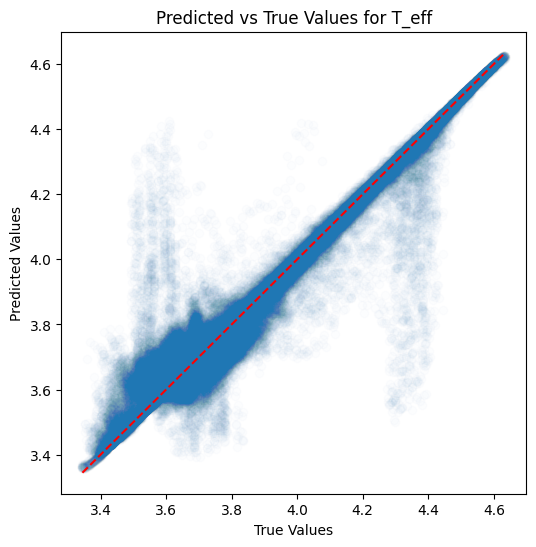

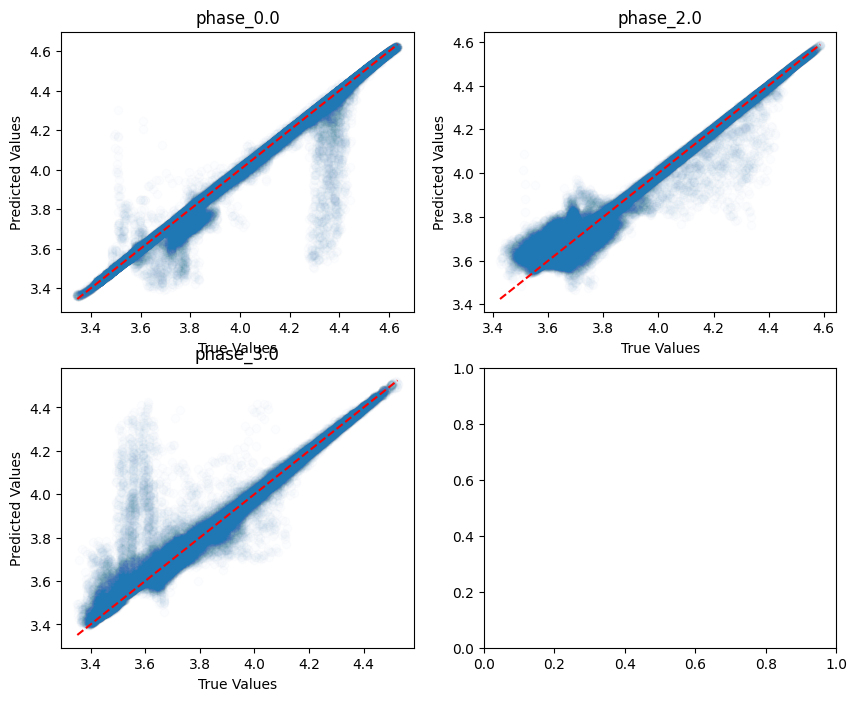

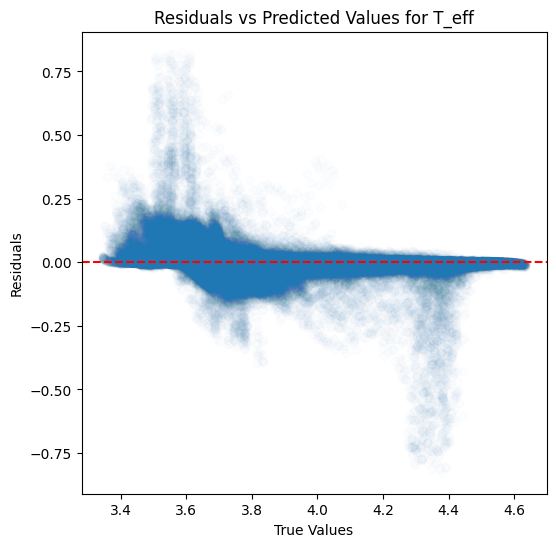

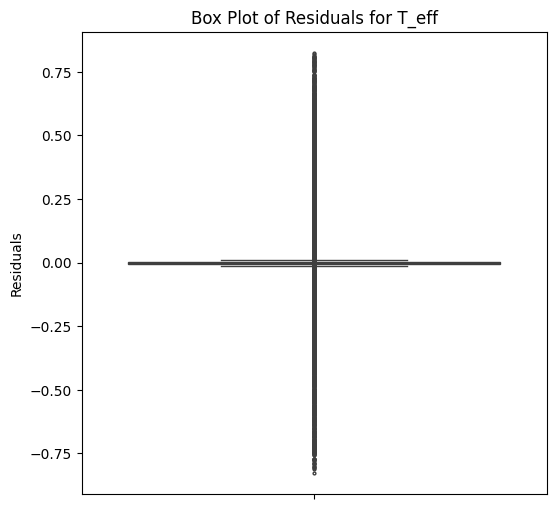

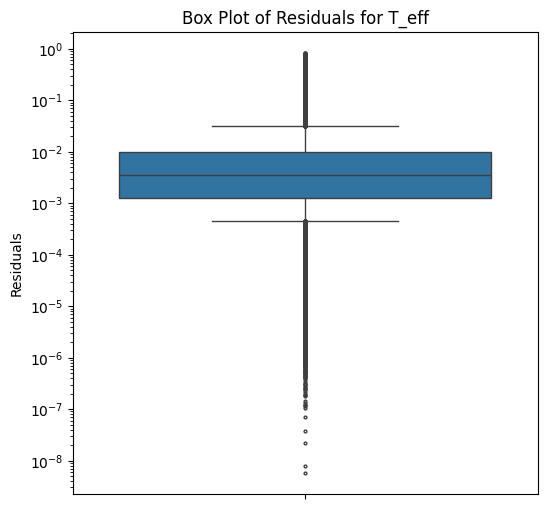

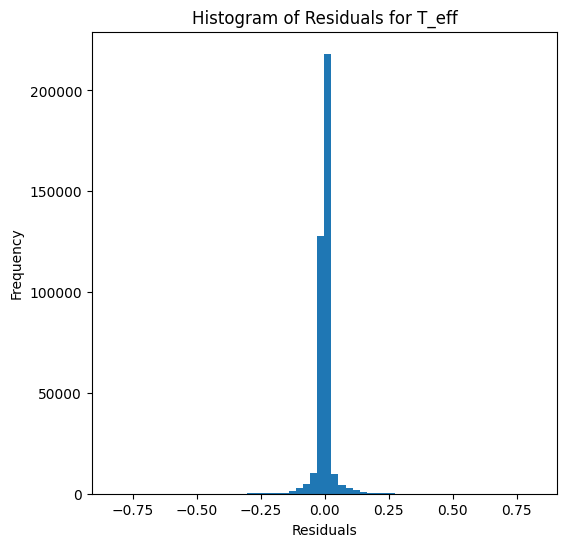

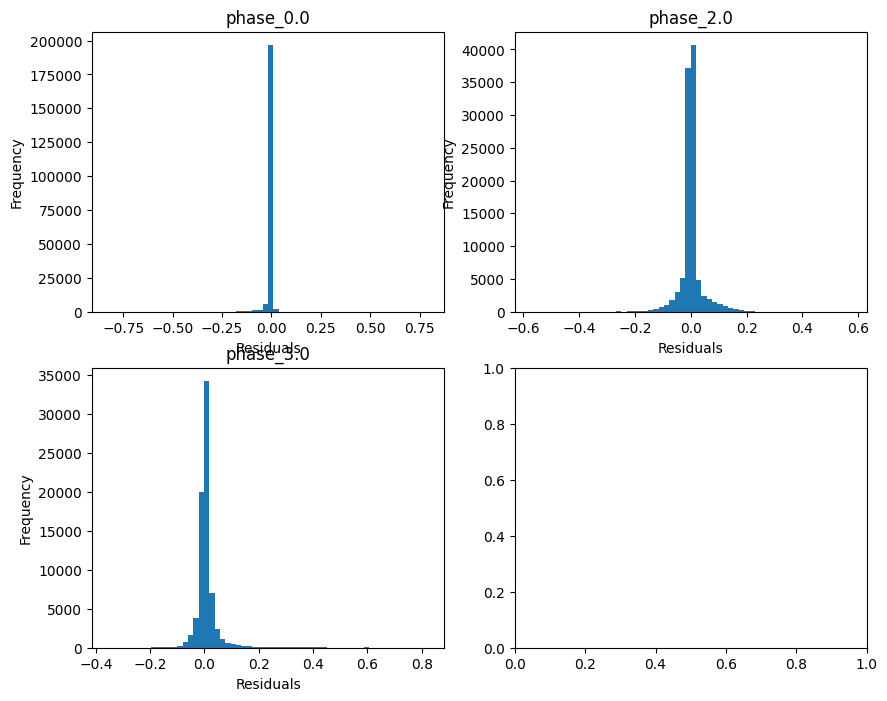

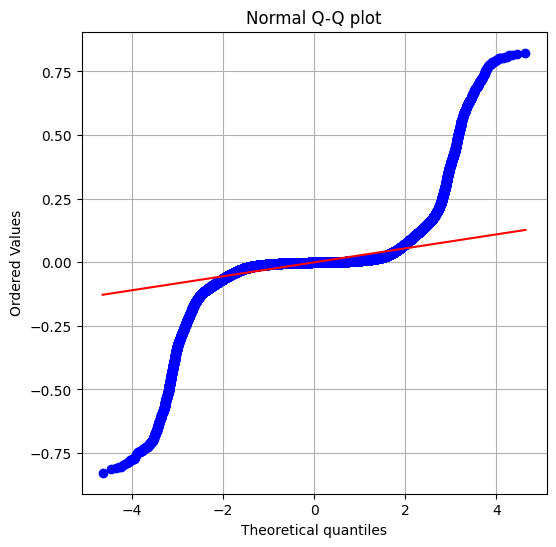

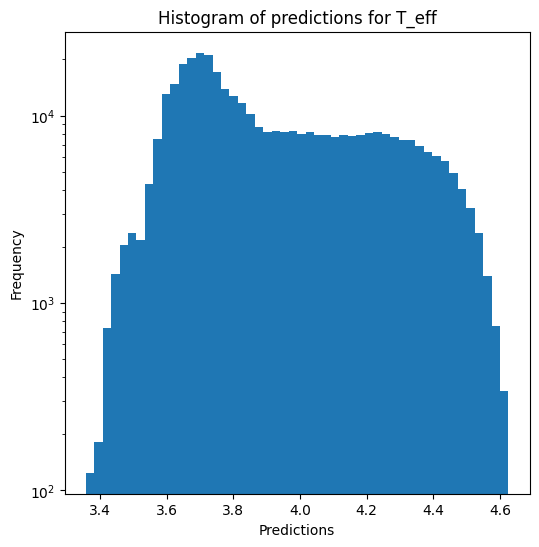

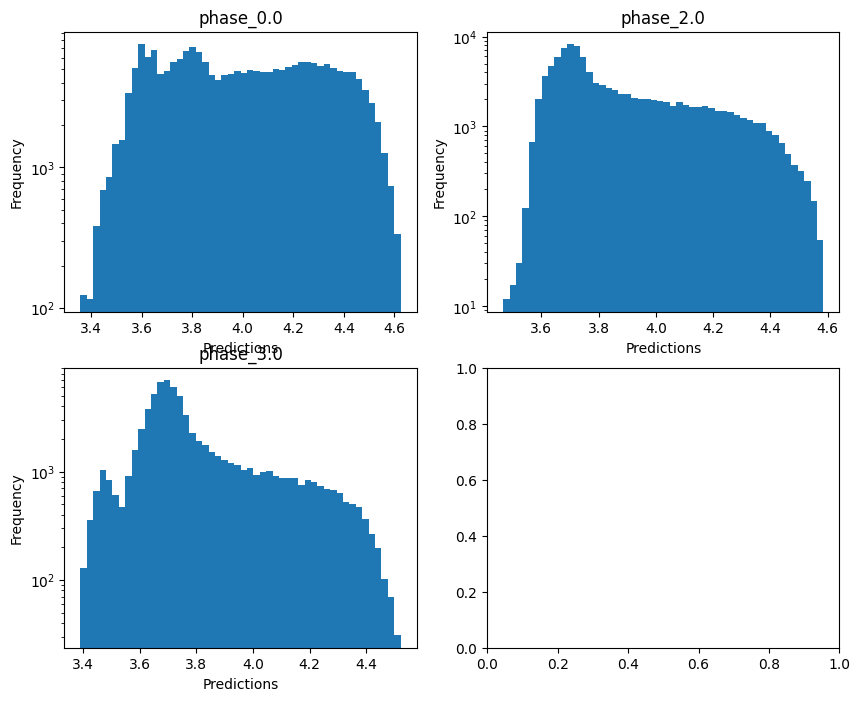


log_g results for the phase category with a value of 0.0
  value range :  -0.5973100835175252 - 5.433094523832443
  RVE :  0.6039025855980796
  RMSE :  0.29166934641814046
  MAE :  0.057349652614707376
  MedAE :  0.0059247704946781
  CORR :  0.8610416325567583
  MAX_ER :  5.188774220234322
  Percentiles : 
    75th percentile :  0.018984925081927173
    90th percentile :  0.05285629256668579
    95th percentile :  0.12180430147991912
    99th percentile :  1.6288910338294558

log_g results for the phase category with a value of 2.0
  value range :  -0.3287802371627256 - 4.4079093481651865
  RVE :  0.5412204284416062
  RMSE :  0.6291757271227412
  MAE :  0.3008847105852845
  MedAE :  0.03186735779785366
  CORR :  0.7397522921331215
  MAX_ER :  4.074103083678687
  Percentiles : 
    75th percentile :  0.3089390563744434
    90th percentile :  1.1200507587209547
    95th percentile :  1.5773287655828685
    99th percentile :  2.3951622813838913

log_g results for the phase category with 

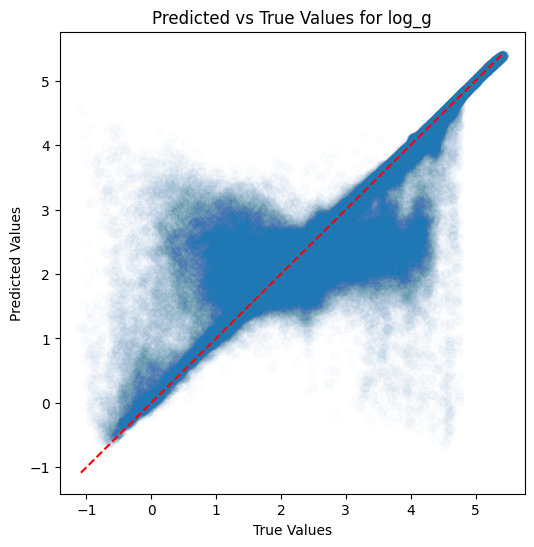

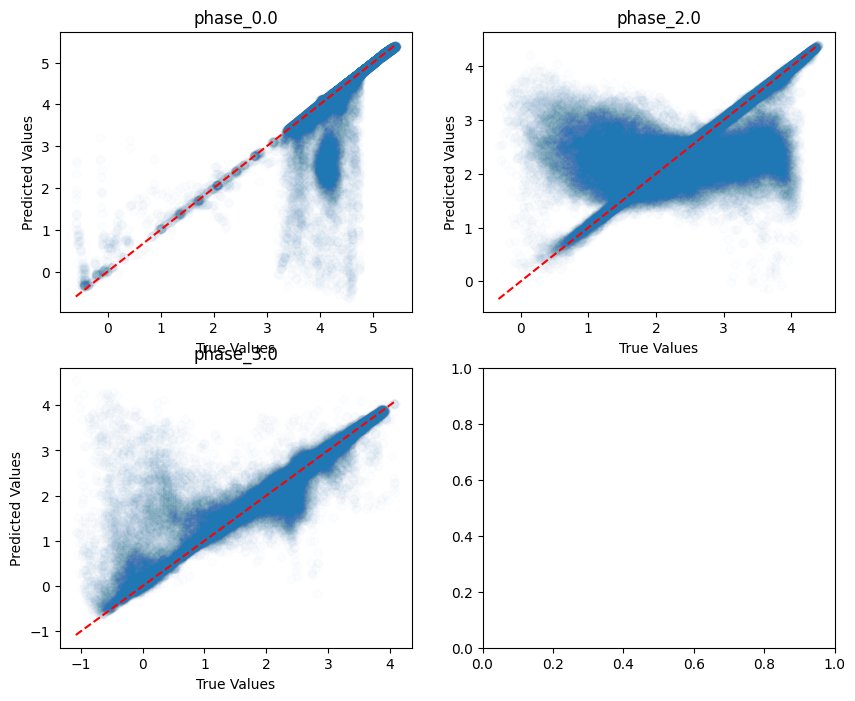

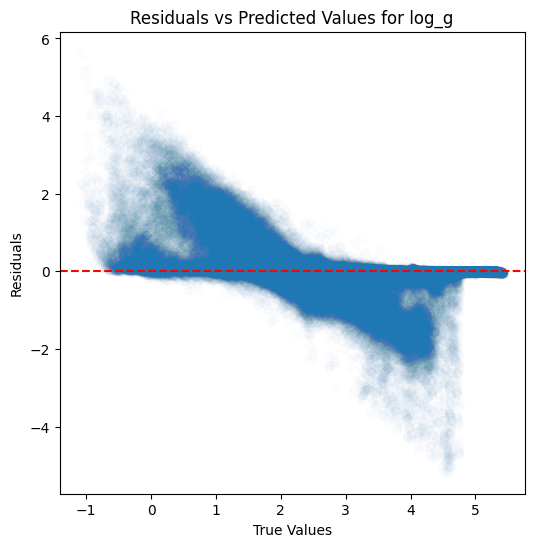

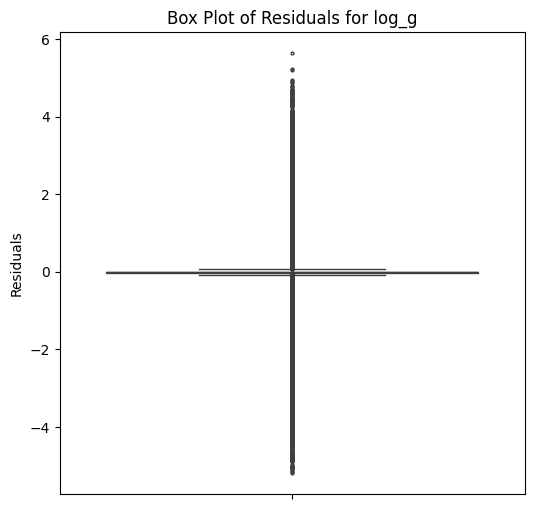

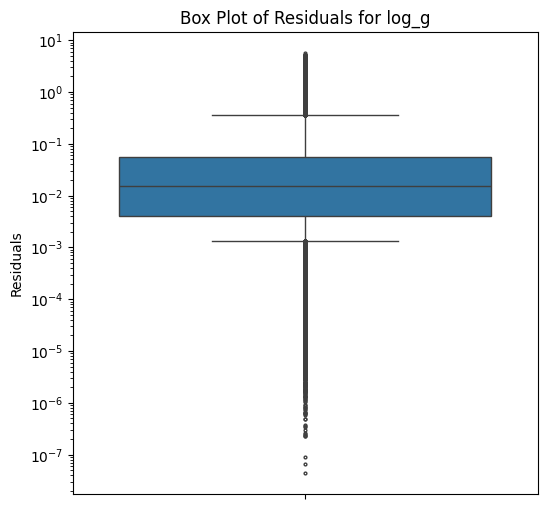

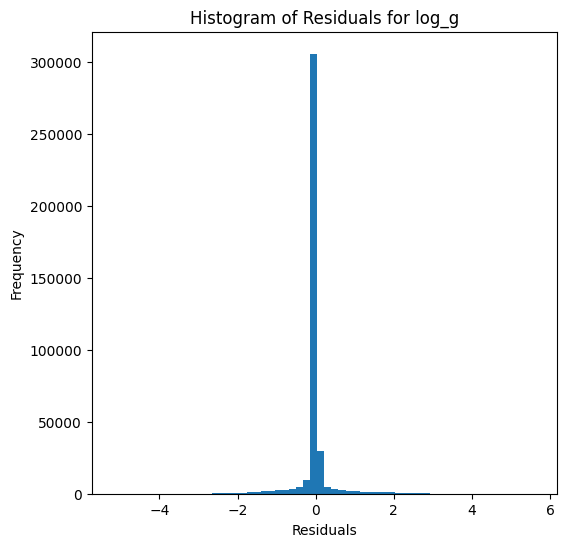

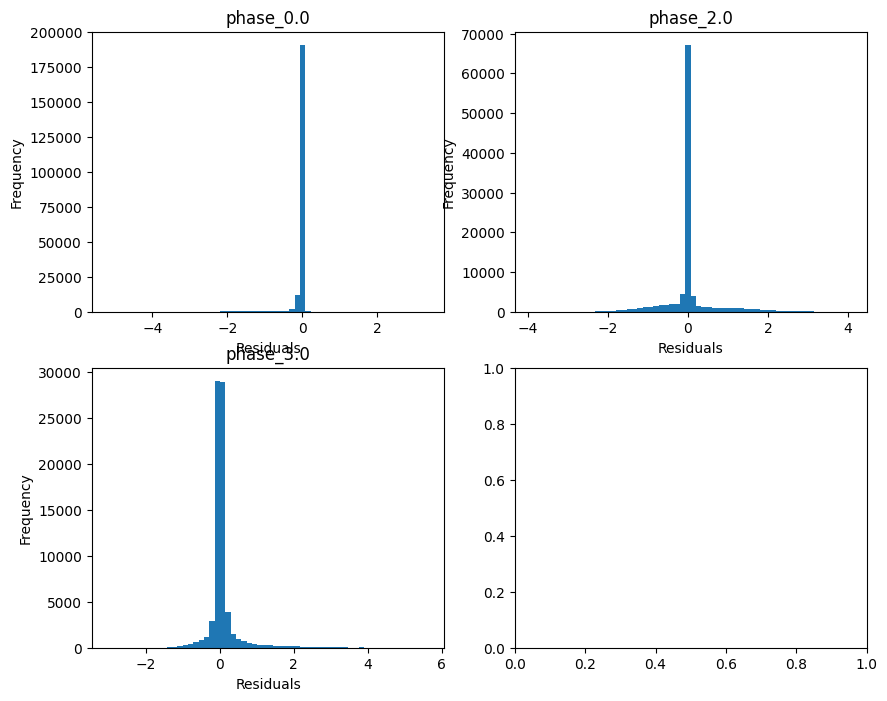

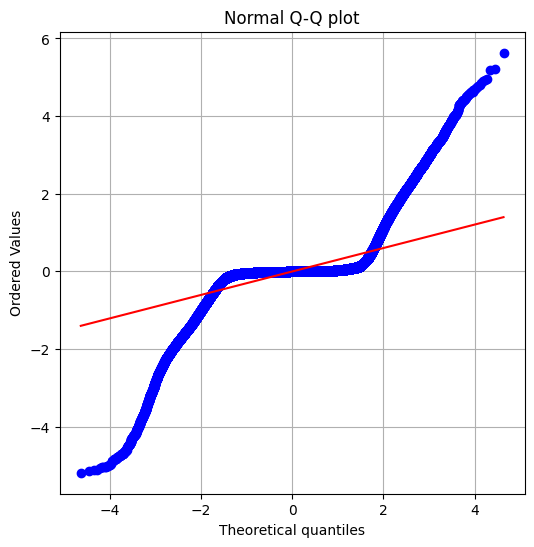

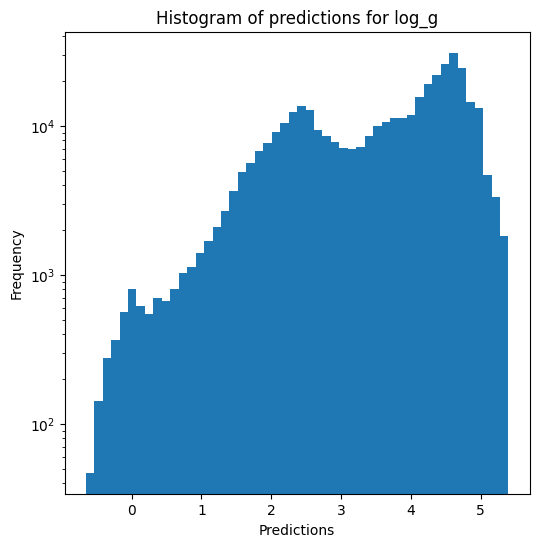

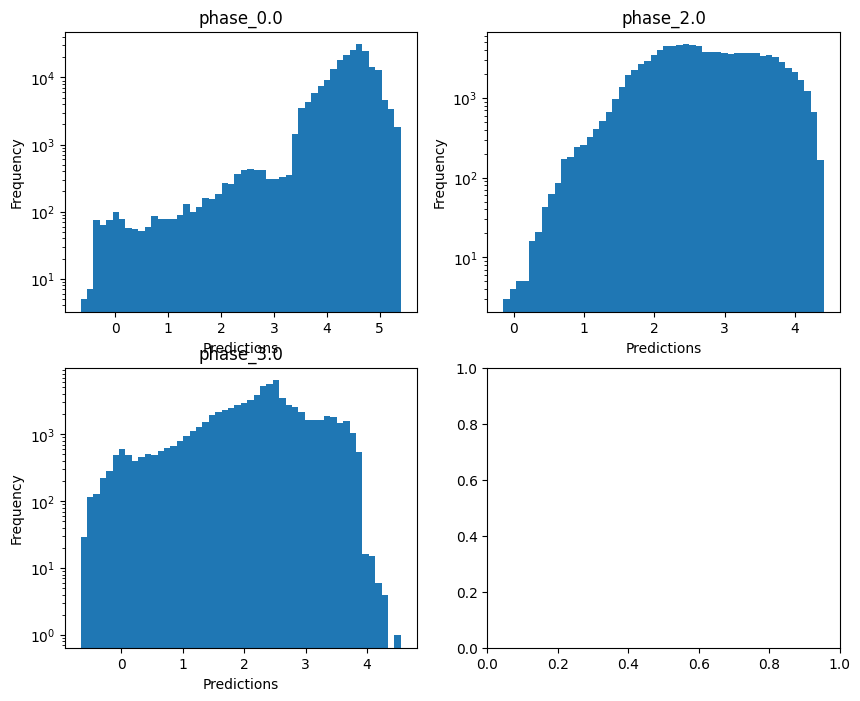

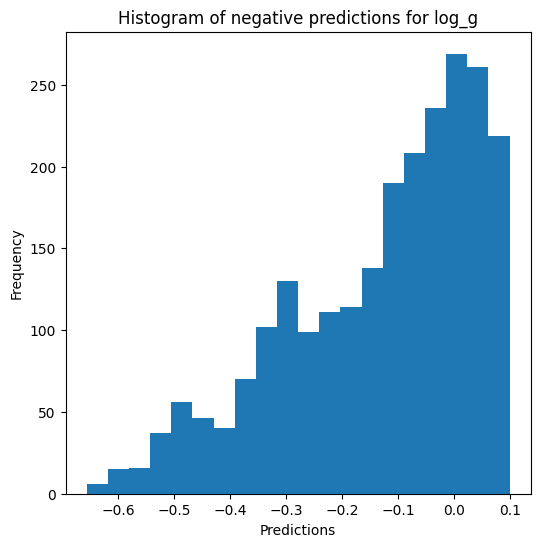


radius results for the phase category with a value of 0.0
  value range :  -0.9974747647513328 - 3.082068881511837
  RVE :  0.883982581213098
  RMSE :  0.145894508765094
  MAE :  0.02947965501333723
  MedAE :  0.003941964166228273
  CORR :  0.947880934097973
  MAX_ER :  2.5957770547352688
  Percentiles : 
    75th percentile :  0.01100955635651979
    90th percentile :  0.027735497112545443
    95th percentile :  0.061140529854218285
    99th percentile :  0.8144012007651659

radius results for the phase category with a value of 2.0
  value range :  0.0909920840275404 - 2.8708569524681256
  RVE :  0.5441439065949956
  RMSE :  0.314581551064088
  MAE :  0.15044088900544525
  MedAE :  0.015943385252200515
  CORR :  0.7451427149422131
  MAX_ER :  2.0369808046557702
  Percentiles : 
    75th percentile :  0.15448868213628053
    90th percentile :  0.5600257108395357
    95th percentile :  0.7886345680776278
    99th percentile :  1.1977032333642044

radius results for the phase category w

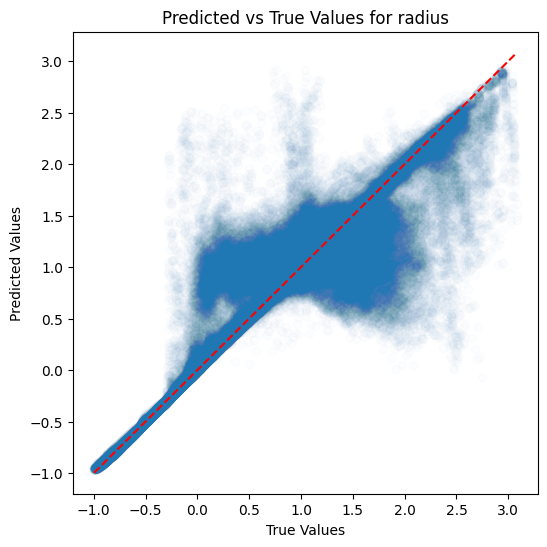

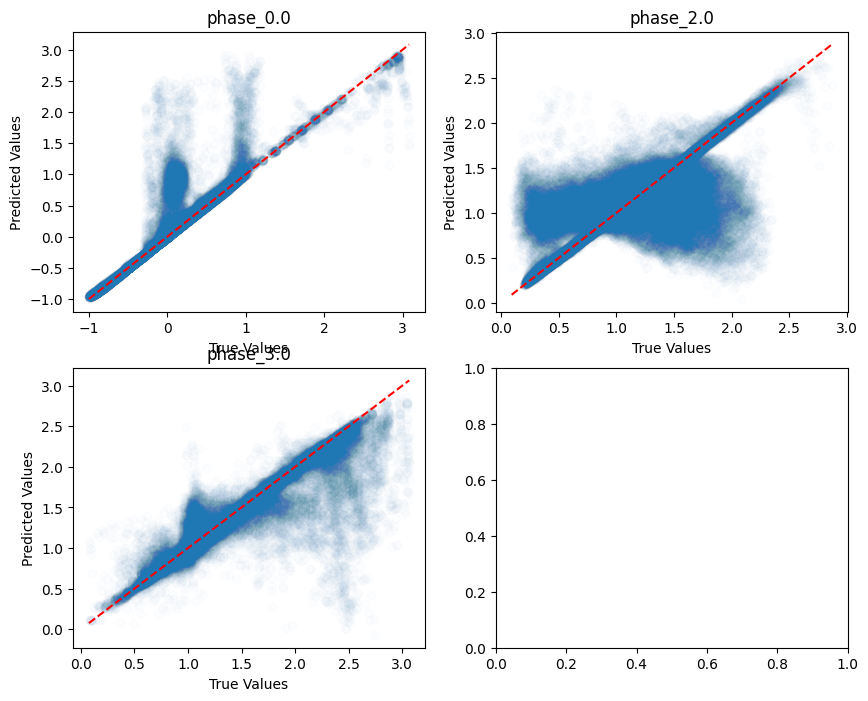

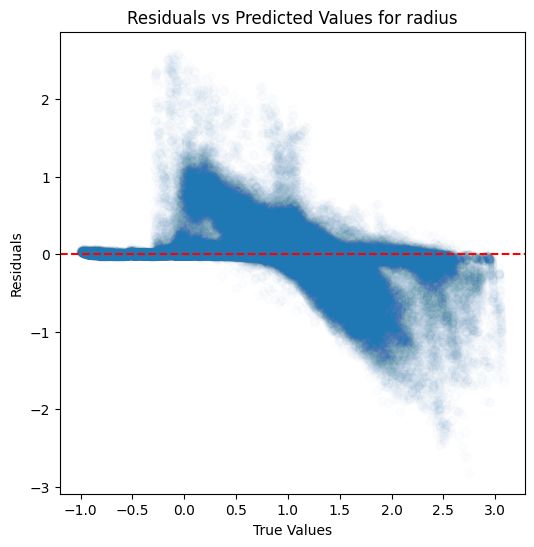

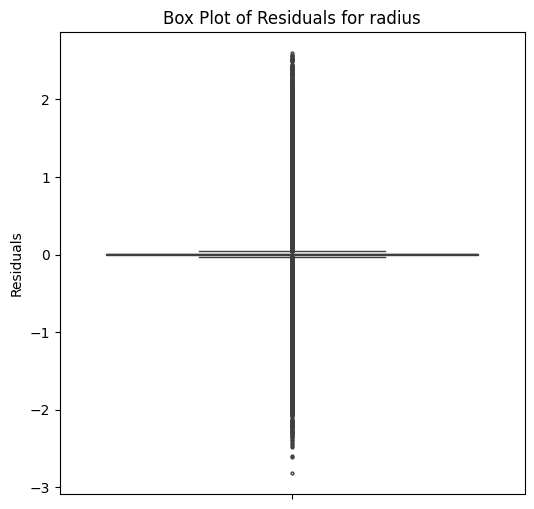

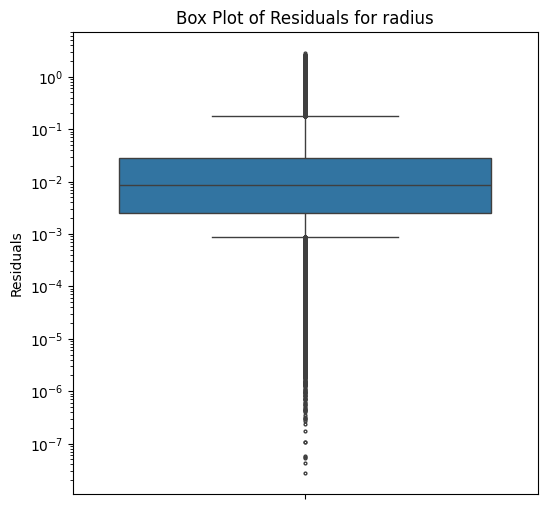

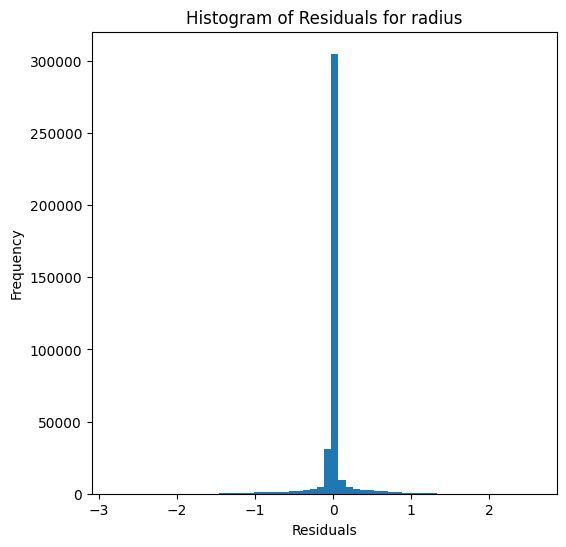

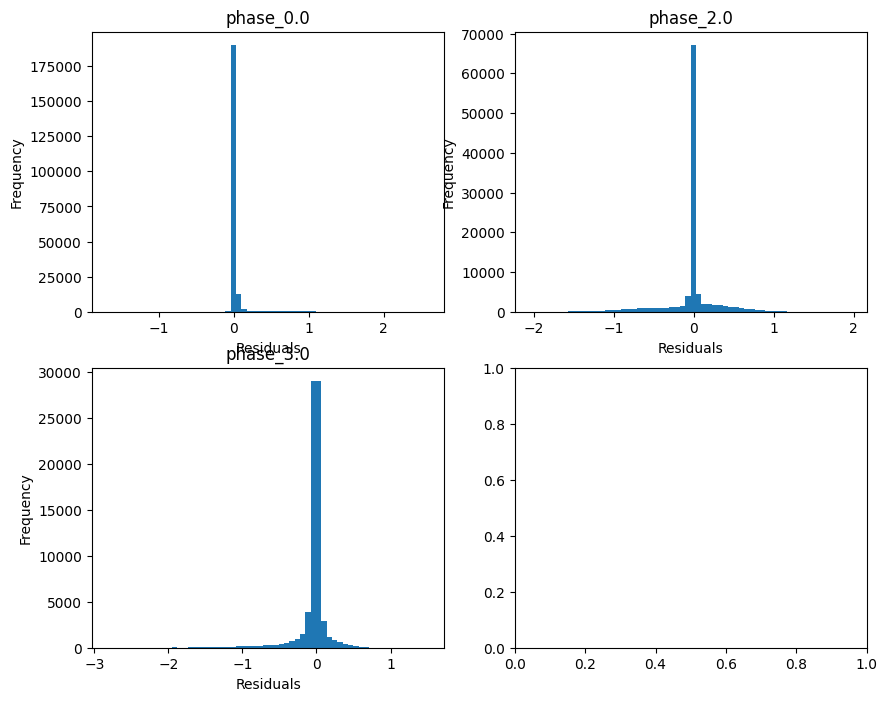

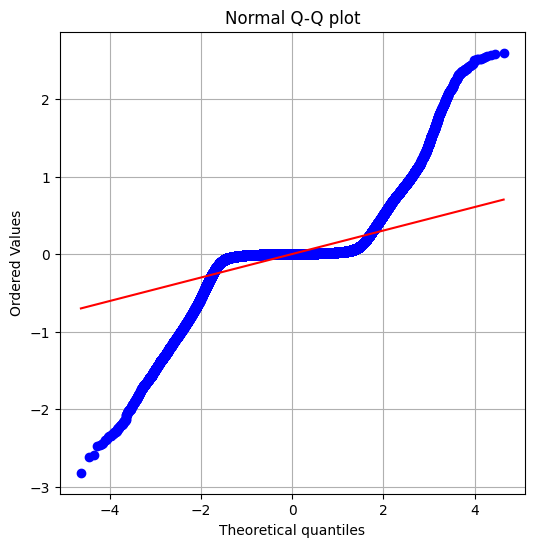

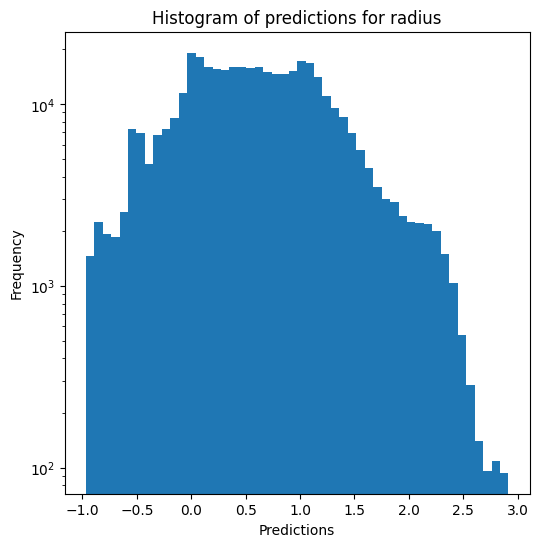

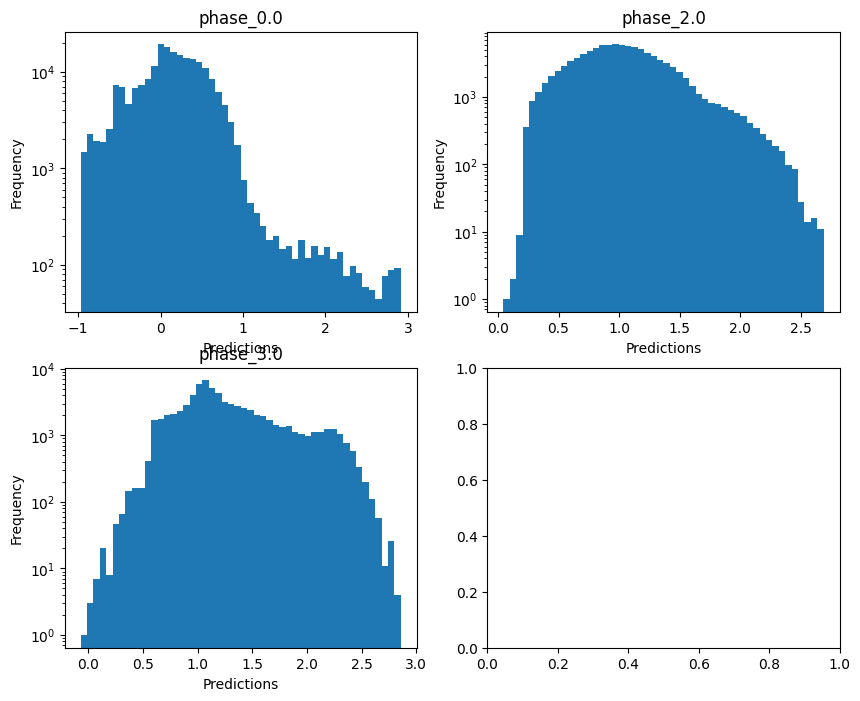

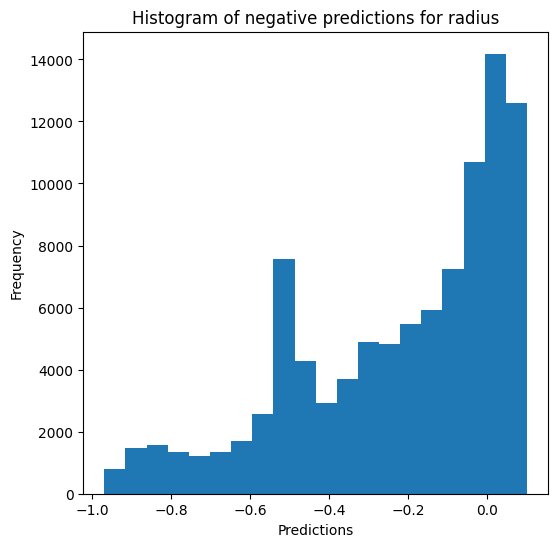

Saving predictions and results...


In [13]:
best_params_RF = {'n_jobs':10, 'n_estimators': 300, 'criterion': 'friedman_mse', 'max_depth': 100, 'min_samples_leaf': 5, 'min_samples_split': 10, 'max_features': 'log2', 'max_leaf_nodes': None}

print(path_to_results)
dt_evaluator = Model_evaluator("random_forest", path=path_to_results, physical_model=physical_model, output_parameters=output_parameters)
dt_evaluator.evaluate_Kfold_results(RandomForestRegressor, X_train, y_train, categories_train, categories_name, path_to_predictions, tag, random_state=12, override=override, use_preds=use_preds, save=save, show=show, scaler_name="quantile", **best_params_RF)

### K nearest neighbours

In [14]:
tag = "scale_quantile_14"

#### Testing the uniform weights with brute strength

In [15]:
cv_params = {'n_neighbors' : [5, 10, 20, 30, 50],
             'weights' : ["uniform"],
             'algorithm' : ["brute"]
            }

gscv_knn = GridSearchCV(KNeighborsRegressor(n_jobs = 10,
                                             ),
                         param_grid = cv_params,
                         scoring = scoring,
                         cv = 10,
                         verbose = 2,
                         refit="neg_root_mean_squared_error"
)

gscv_knn.fit(X_train_quantile, y_train)
display_grid_search(gscv_knn)

Fitting 10 folds for each of 5 candidates, totalling 50 fits
[CV] END ....algorithm=brute, n_neighbors=5, weights=uniform; total time=   5.6s
[CV] END ....algorithm=brute, n_neighbors=5, weights=uniform; total time=   4.0s
[CV] END ....algorithm=brute, n_neighbors=5, weights=uniform; total time=   3.9s
[CV] END ....algorithm=brute, n_neighbors=5, weights=uniform; total time=   3.9s
[CV] END ....algorithm=brute, n_neighbors=5, weights=uniform; total time=   3.8s
[CV] END ....algorithm=brute, n_neighbors=5, weights=uniform; total time=   3.8s
[CV] END ....algorithm=brute, n_neighbors=5, weights=uniform; total time=   3.9s
[CV] END ....algorithm=brute, n_neighbors=5, weights=uniform; total time=   3.9s
[CV] END ....algorithm=brute, n_neighbors=5, weights=uniform; total time=   3.8s
[CV] END ....algorithm=brute, n_neighbors=5, weights=uniform; total time=   3.8s
[CV] END ...algorithm=brute, n_neighbors=10, weights=uniform; total time=   3.9s
[CV] END ...algorithm=brute, n_neighbors=10, wei

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_algorithm,param_n_neighbors,param_weights,params,split0_test_neg_root_mean_squared_error,split1_test_neg_root_mean_squared_error,split2_test_neg_root_mean_squared_error,split3_test_neg_root_mean_squared_error,split4_test_neg_root_mean_squared_error,split5_test_neg_root_mean_squared_error,split6_test_neg_root_mean_squared_error,split7_test_neg_root_mean_squared_error,split8_test_neg_root_mean_squared_error,split9_test_neg_root_mean_squared_error,mean_test_neg_root_mean_squared_error,std_test_neg_root_mean_squared_error,rank_test_neg_root_mean_squared_error,split0_test_neg_mean_absolute_error,split1_test_neg_mean_absolute_error,split2_test_neg_mean_absolute_error,split3_test_neg_mean_absolute_error,split4_test_neg_mean_absolute_error,split5_test_neg_mean_absolute_error,split6_test_neg_mean_absolute_error,split7_test_neg_mean_absolute_error,split8_test_neg_mean_absolute_error,split9_test_neg_mean_absolute_error,mean_test_neg_mean_absolute_error,std_test_neg_mean_absolute_error,rank_test_neg_mean_absolute_error
0,0.011925,0.003149,4.117451,0.509053,brute,5,uniform,"{'algorithm': 'brute', 'n_neighbors': 5, 'weig...",-0.240484,-0.237661,-0.237986,-0.234875,-0.240760,-0.230819,-0.231787,-0.234123,-0.238340,-0.241006,-0.236784,0.003510,3,-0.072019,-0.071009,-0.071170,-0.070385,-0.070542,-0.069373,-0.068790,-0.069017,-0.071914,-0.072183,-0.070640,0.001186,1
1,0.010967,0.004199,3.943024,0.047953,brute,10,uniform,"{'algorithm': 'brute', 'n_neighbors': 10, 'wei...",-0.229927,-0.227983,-0.227991,-0.225642,-0.231498,-0.221681,-0.222530,-0.224273,-0.230638,-0.230401,-0.227256,0.003353,1,-0.074705,-0.074032,-0.074244,-0.073639,-0.073665,-0.072532,-0.072200,-0.072326,-0.075527,-0.075138,-0.073801,0.001106,2
2,0.009985,0.002617,3.958403,0.044465,brute,20,uniform,"{'algorithm': 'brute', 'n_neighbors': 20, 'wei...",-0.233556,-0.232748,-0.232238,-0.231774,-0.234625,-0.227782,-0.227738,-0.229190,-0.234183,-0.236381,-0.232022,0.002789,2,-0.085936,-0.085458,-0.086150,-0.085397,-0.084955,-0.084661,-0.083908,-0.084294,-0.086901,-0.087154,-0.085482,0.001015,3
3,0.012160,0.001920,3.916914,0.042371,brute,30,uniform,"{'algorithm': 'brute', 'n_neighbors': 30, 'wei...",-0.242468,-0.240595,-0.241607,-0.242521,-0.243329,-0.237543,-0.236073,-0.238483,-0.241293,-0.244543,-0.240846,0.002557,4,-0.098563,-0.097583,-0.098764,-0.098212,-0.096976,-0.097456,-0.096381,-0.096966,-0.098859,-0.099440,-0.097920,0.000943,4
4,0.011836,0.002585,3.988147,0.029067,brute,50,uniform,"{'algorithm': 'brute', 'n_neighbors': 50, 'wei...",-0.259926,-0.260418,-0.259195,-0.261370,-0.260193,-0.257826,-0.254975,-0.255624,-0.257897,-0.261755,-0.258918,0.002183,5,-0.121184,-0.120729,-0.121394,-0.120821,-0.119610,-0.120819,-0.119626,-0.119304,-0.121375,-0.121938,-0.120680,0.000838,5


Best parameters {'algorithm': 'brute', 'n_neighbors': 10, 'weights': 'uniform'}
Best score -0.22725641019932374


#### Testing the uniform weights with algorithms

In [16]:
cv_params = {'n_neighbors' : [5, 10, 20, 30, 50],
             'weights' : ["uniform"],
             'algorithm' : ["ball_tree", "kd_tree"],
             'leaf_size' : [15, 30, 50, 75, 100]
            }

gscv_knn = GridSearchCV(KNeighborsRegressor(n_jobs = 10,
                                             ),
                         param_grid = cv_params,
                         scoring = scoring,
                         cv = 10,
                         verbose = 2,
                         refit="neg_root_mean_squared_error"
)

gscv_knn.fit(X_train_quantile, y_train)
display_grid_search(gscv_knn)

Fitting 10 folds for each of 50 candidates, totalling 500 fits
[CV] END algorithm=ball_tree, leaf_size=15, n_neighbors=5, weights=uniform; total time=   1.0s
[CV] END algorithm=ball_tree, leaf_size=15, n_neighbors=5, weights=uniform; total time=   0.9s
[CV] END algorithm=ball_tree, leaf_size=15, n_neighbors=5, weights=uniform; total time=   0.9s
[CV] END algorithm=ball_tree, leaf_size=15, n_neighbors=5, weights=uniform; total time=   1.0s
[CV] END algorithm=ball_tree, leaf_size=15, n_neighbors=5, weights=uniform; total time=   1.0s
[CV] END algorithm=ball_tree, leaf_size=15, n_neighbors=5, weights=uniform; total time=   1.0s
[CV] END algorithm=ball_tree, leaf_size=15, n_neighbors=5, weights=uniform; total time=   0.9s
[CV] END algorithm=ball_tree, leaf_size=15, n_neighbors=5, weights=uniform; total time=   1.0s
[CV] END algorithm=ball_tree, leaf_size=15, n_neighbors=5, weights=uniform; total time=   1.0s
[CV] END algorithm=ball_tree, leaf_size=15, n_neighbors=5, weights=uniform; total 

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_algorithm,param_leaf_size,param_n_neighbors,param_weights,params,split0_test_neg_root_mean_squared_error,split1_test_neg_root_mean_squared_error,split2_test_neg_root_mean_squared_error,split3_test_neg_root_mean_squared_error,split4_test_neg_root_mean_squared_error,split5_test_neg_root_mean_squared_error,split6_test_neg_root_mean_squared_error,split7_test_neg_root_mean_squared_error,split8_test_neg_root_mean_squared_error,split9_test_neg_root_mean_squared_error,mean_test_neg_root_mean_squared_error,std_test_neg_root_mean_squared_error,rank_test_neg_root_mean_squared_error,split0_test_neg_mean_absolute_error,split1_test_neg_mean_absolute_error,split2_test_neg_mean_absolute_error,split3_test_neg_mean_absolute_error,split4_test_neg_mean_absolute_error,split5_test_neg_mean_absolute_error,split6_test_neg_mean_absolute_error,split7_test_neg_mean_absolute_error,split8_test_neg_mean_absolute_error,split9_test_neg_mean_absolute_error,mean_test_neg_mean_absolute_error,std_test_neg_mean_absolute_error,rank_test_neg_mean_absolute_error
0,0.229118,0.019324,0.851654,0.034771,ball_tree,15,5,uniform,"{'algorithm': 'ball_tree', 'leaf_size': 15, 'n...",-0.240475,-0.237659,-0.237986,-0.234878,-0.240761,-0.230820,-0.231786,-0.234123,-0.238341,-0.241006,-0.236784,0.003509,21,-0.072015,-0.071006,-0.071169,-0.070385,-0.070541,-0.069371,-0.068788,-0.069015,-0.071915,-0.072182,-0.070639,0.001186,1
1,0.228363,0.010780,0.923450,0.034166,ball_tree,15,10,uniform,"{'algorithm': 'ball_tree', 'leaf_size': 15, 'n...",-0.229927,-0.227983,-0.227991,-0.225642,-0.231498,-0.221681,-0.222530,-0.224273,-0.230638,-0.230401,-0.227256,0.003353,1,-0.074704,-0.074032,-0.074243,-0.073638,-0.073665,-0.072531,-0.072199,-0.072325,-0.075527,-0.075137,-0.073800,0.001106,11
2,0.215197,0.012417,1.111562,0.045917,ball_tree,15,20,uniform,"{'algorithm': 'ball_tree', 'leaf_size': 15, 'n...",-0.233556,-0.232748,-0.232238,-0.231774,-0.234625,-0.227782,-0.227738,-0.229190,-0.234183,-0.236381,-0.232022,0.002789,11,-0.085936,-0.085458,-0.086150,-0.085397,-0.084955,-0.084661,-0.083908,-0.084294,-0.086901,-0.087154,-0.085481,0.001015,21
3,0.217684,0.008462,1.245966,0.058910,ball_tree,15,30,uniform,"{'algorithm': 'ball_tree', 'leaf_size': 15, 'n...",-0.242468,-0.240595,-0.241607,-0.242521,-0.243329,-0.237543,-0.236073,-0.238483,-0.241293,-0.244543,-0.240846,0.002557,31,-0.098563,-0.097583,-0.098764,-0.098212,-0.096976,-0.097456,-0.096381,-0.096966,-0.098859,-0.099440,-0.097920,0.000943,31
4,0.238347,0.023053,1.510107,0.085129,ball_tree,15,50,uniform,"{'algorithm': 'ball_tree', 'leaf_size': 15, 'n...",-0.259926,-0.260418,-0.259195,-0.261370,-0.260193,-0.257826,-0.254975,-0.255624,-0.257897,-0.261755,-0.258918,0.002183,41,-0.121184,-0.120729,-0.121394,-0.120821,-0.119610,-0.120819,-0.119626,-0.119304,-0.121375,-0.121938,-0.120680,0.000838,41
5,0.203940,0.005387,1.027586,0.053640,ball_tree,30,5,uniform,"{'algorithm': 'ball_tree', 'leaf_size': 30, 'n...",-0.240475,-0.237659,-0.237986,-0.234878,-0.240761,-0.230820,-0.231786,-0.234123,-0.238341,-0.241006,-0.236784,0.003509,21,-0.072015,-0.071006,-0.071169,-0.070385,-0.070541,-0.069371,-0.068788,-0.069015,-0.071915,-0.072182,-0.070639,0.001186,1
6,0.201320,0.012015,1.138979,0.048955,ball_tree,30,10,uniform,"{'algorithm': 'ball_tree', 'leaf_size': 30, 'n...",-0.229927,-0.227983,-0.227991,-0.225642,-0.231498,-0.221681,-0.222530,-0.224273,-0.230638,-0.230401,-0.227256,0.003353,1,-0.074704,-0.074032,-0.074243,-0.073638,-0.073665,-0.072531,-0.072199,-0.072325,-0.075527,-0.075137,-0.073800,0.001106,11
7,0.220204,0.026392,1.332574,0.048723,ball_tree,30,20,uniform,"{'algorithm': 'ball_tree', 'leaf_size': 30, 'n...",-0.233556,-0.232748,-0.232238,-0.231774,-0.234625,-0.227782,-0.227738,-0.229190,-0.234183,-0.236381,-0.232022,0.002789,11,-0.085936,-0.085458,-0.086150,-0.085397,-0.084955,-0.084661,-0.083908,-0.084294,-0.086901,-0.087154,-0.085481,0.001015,21
8,0.225562,0.027373,1.574298,0.113226,

Best parameters {'algorithm': 'ball_tree', 'leaf_size': 15, 'n_neighbors': 10, 'weights': 'uniform'}
Best score -0.2272564033581089


the algorithms give almost the same results then brute force with much less time. It is better to use them with distance calculation

#### Testing the distance weights with algorithms

In [17]:
cv_params = {'n_neighbors' : [5, 25, 50],
             'weights' : ["distance"],
             'algorithm' : ["ball_tree", "kd_tree"],
             'leaf_size' : [15, 50, 100],
             'p' : [1.0, 1.3, 1.6, 2.0]
            }

gscv_knn_1 = GridSearchCV(KNeighborsRegressor(n_jobs = 10,
                                             ),
                         param_grid = cv_params,
                         scoring = scoring,
                         cv = 10,
                         verbose = 2,
                         refit="neg_root_mean_squared_error"
)

gscv_knn_1.fit(X_train_quantile, y_train)
display_grid_search(gscv_knn_1)

Fitting 10 folds for each of 72 candidates, totalling 720 fits
[CV] END algorithm=ball_tree, leaf_size=15, n_neighbors=5, p=1.0, weights=distance; total time=   0.7s
[CV] END algorithm=ball_tree, leaf_size=15, n_neighbors=5, p=1.0, weights=distance; total time=   0.9s
[CV] END algorithm=ball_tree, leaf_size=15, n_neighbors=5, p=1.0, weights=distance; total time=   1.0s
[CV] END algorithm=ball_tree, leaf_size=15, n_neighbors=5, p=1.0, weights=distance; total time=   1.0s
[CV] END algorithm=ball_tree, leaf_size=15, n_neighbors=5, p=1.0, weights=distance; total time=   0.9s
[CV] END algorithm=ball_tree, leaf_size=15, n_neighbors=5, p=1.0, weights=distance; total time=   0.9s
[CV] END algorithm=ball_tree, leaf_size=15, n_neighbors=5, p=1.0, weights=distance; total time=   1.0s
[CV] END algorithm=ball_tree, leaf_size=15, n_neighbors=5, p=1.0, weights=distance; total time=   0.8s
[CV] END algorithm=ball_tree, leaf_size=15, n_neighbors=5, p=1.0, weights=distance; total time=   0.9s
[CV] END a

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_algorithm,param_leaf_size,param_n_neighbors,param_p,param_weights,params,split0_test_neg_root_mean_squared_error,split1_test_neg_root_mean_squared_error,split2_test_neg_root_mean_squared_error,split3_test_neg_root_mean_squared_error,split4_test_neg_root_mean_squared_error,split5_test_neg_root_mean_squared_error,split6_test_neg_root_mean_squared_error,split7_test_neg_root_mean_squared_error,split8_test_neg_root_mean_squared_error,split9_test_neg_root_mean_squared_error,mean_test_neg_root_mean_squared_error,std_test_neg_root_mean_squared_error,rank_test_neg_root_mean_squared_error,split0_test_neg_mean_absolute_error,split1_test_neg_mean_absolute_error,split2_test_neg_mean_absolute_error,split3_test_neg_mean_absolute_error,split4_test_neg_mean_absolute_error,split5_test_neg_mean_absolute_error,split6_test_neg_mean_absolute_error,split7_test_neg_mean_absolute_error,split8_test_neg_mean_absolute_error,split9_test_neg_mean_absolute_error,mean_test_neg_mean_absolute_error,std_test_neg_mean_absolute_error,rank_test_neg_mean_absolute_error
0,0.249740,0.014308,0.764237,0.080724,ball_tree,15,5,1.0,distance,"{'algorithm': 'ball_tree', 'leaf_size': 15, 'n...",-0.283942,-0.281355,-0.282153,-0.277988,-0.282718,-0.275687,-0.274155,-0.275106,-0.284050,-0.286211,-0.280337,0.004050,49,-0.082801,-0.081521,-0.081822,-0.080719,-0.081027,-0.079902,-0.078987,-0.078800,-0.082647,-0.083318,-0.081154,0.001490,19
1,0.436653,0.023311,1.324356,0.093511,ball_tree,15,5,1.3,distance,"{'algorithm': 'ball_tree', 'leaf_size': 15, 'n...",-0.283894,-0.281348,-0.282198,-0.278018,-0.282734,-0.275689,-0.274156,-0.275031,-0.284186,-0.286259,-0.280351,0.004076,55,-0.082783,-0.081527,-0.081826,-0.080713,-0.081024,-0.079901,-0.078978,-0.078793,-0.082661,-0.083315,-0.081152,0.001493,13
2,0.402643,0.011275,1.567691,0.129711,ball_tree,15,5,1.6,distance,"{'algorithm': 'ball_tree', 'leaf_size': 15, 'n...",-0.283889,-0.281397,-0.282198,-0.277997,-0.282706,-0.275802,-0.274186,-0.275026,-0.284151,-0.286219,-0.280357,0.004050,61,-0.082781,-0.081529,-0.081820,-0.080708,-0.081008,-0.079916,-0.078995,-0.078782,-0.082643,-0.083302,-0.081148,0.001487,1
3,0.231251,0.017771,0.923293,0.017580,ball_tree,15,5,2.0,distance,"{'algorithm': 'ball_tree', 'leaf_size': 15, 'n...",-0.283866,-0.281397,-0.282176,-0.278016,-0.282708,-0.275836,-0.274223,-0.275051,-0.284156,-0.286214,-0.280364,0.004033,67,-0.082775,-0.081528,-0.081820,-0.080714,-0.081015,-0.079927,-0.079011,-0.078788,-0.082643,-0.083295,-0.081152,0.001481,7
4,0.227570,0.011637,1.228828,0.105441,ball_tree,15,25,1.0,distance,"{'algorithm': 'ball_tree', 'leaf_size': 15, 'n...",-0.263983,-0.261795,-0.262909,-0.259908,-0.264140,-0.257705,-0.256405,-0.257261,-0.265138,-0.267026,-0.261627,0.003460,7,-0.087970,-0.087205,-0.087639,-0.086707,-0.086639,-0.085874,-0.085158,-0.085005,-0.088370,-0.088964,-0.086953,0.001263,31
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
67,0.211871,0.014960,0.492527,0.017014,kd_tree,100,25,2.0,distance,"{'algorithm': 'kd_tree', 'leaf_size': 100, 'n_...",-0.264087,-0.262054,-0.263342,-0.259989,-0.264587,-0.258234,-0.256474,-0.257710,-0.265480,-0.267169,-0.261913,0.003446,31,-0.087949,-0.087184,-0.087695,-0.086659,-0.086695,-0.085935,-0.085096,-0.085057,-0.088399,-0.088926,-0.086960,0.001257,43
68,0.206072,0.011603,0.748572,0.122948,kd_tree,100,50,1.0,distance,"{'algorithm': 'kd_tree', 'leaf_size': 100, 'n_...",-0.262832,-0.261377,-0.262760,-0.261104,-0.263589,-0.258906,-0.256415,-0.257350,-0.264166,-0.266427,-0.261493,0.002985,1,-0.097228,-0.096886,-0.097432,-0.096728,-0.096259,-0.095971,-0.094913,-0.094824,-0.097970,-0.098632,-0.096684,0.001168,49
69,0.233095,0.028521,0.958246,0.071216,kd_tree,100,50,1.3,distance,"{'algorithm': 'kd_tree', 'leaf_size': 100, 'n_...",-0.263029,-0.261840,-0.263086,-0.261306,-0.263882,-0.259221,-0.256634,-0.257729,-0.26453

Best parameters {'algorithm': 'ball_tree', 'leaf_size': 15, 'n_neighbors': 50, 'p': 1.0, 'weights': 'distance'}
Best score -0.261492511136123


In [18]:
cv_params = {'n_neighbors' : [5, 25, 50],
             'weights' : [gaussian],
             'algorithm' : ["ball_tree", "kd_tree"],
             'leaf_size' : [15, 50, 100]
            }

gscv_knn_2 = GridSearchCV(KNeighborsRegressor(n_jobs = 10,
                                             ),
                         param_grid = cv_params,
                         scoring = scoring,
                         cv = 10,
                         verbose = 2,
                         refit="neg_root_mean_squared_error"
)

gscv_knn_2.fit(X_train_quantile, y_train)
display_grid_search(gscv_knn_2)

Fitting 10 folds for each of 18 candidates, totalling 180 fits
[CV] END algorithm=ball_tree, leaf_size=15, n_neighbors=5, weights=<function gaussian at 0x000001FBB1C72FC0>; total time=   1.0s
[CV] END algorithm=ball_tree, leaf_size=15, n_neighbors=5, weights=<function gaussian at 0x000001FBB1C72FC0>; total time=   1.0s
[CV] END algorithm=ball_tree, leaf_size=15, n_neighbors=5, weights=<function gaussian at 0x000001FBB1C72FC0>; total time=   1.1s
[CV] END algorithm=ball_tree, leaf_size=15, n_neighbors=5, weights=<function gaussian at 0x000001FBB1C72FC0>; total time=   1.0s
[CV] END algorithm=ball_tree, leaf_size=15, n_neighbors=5, weights=<function gaussian at 0x000001FBB1C72FC0>; total time=   1.0s
[CV] END algorithm=ball_tree, leaf_size=15, n_neighbors=5, weights=<function gaussian at 0x000001FBB1C72FC0>; total time=   1.0s
[CV] END algorithm=ball_tree, leaf_size=15, n_neighbors=5, weights=<function gaussian at 0x000001FBB1C72FC0>; total time=   1.0s
[CV] END algorithm=ball_tree, leaf

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_algorithm,param_leaf_size,param_n_neighbors,param_weights,params,split0_test_neg_root_mean_squared_error,split1_test_neg_root_mean_squared_error,split2_test_neg_root_mean_squared_error,split3_test_neg_root_mean_squared_error,split4_test_neg_root_mean_squared_error,split5_test_neg_root_mean_squared_error,split6_test_neg_root_mean_squared_error,split7_test_neg_root_mean_squared_error,split8_test_neg_root_mean_squared_error,split9_test_neg_root_mean_squared_error,mean_test_neg_root_mean_squared_error,std_test_neg_root_mean_squared_error,rank_test_neg_root_mean_squared_error,split0_test_neg_mean_absolute_error,split1_test_neg_mean_absolute_error,split2_test_neg_mean_absolute_error,split3_test_neg_mean_absolute_error,split4_test_neg_mean_absolute_error,split5_test_neg_mean_absolute_error,split6_test_neg_mean_absolute_error,split7_test_neg_mean_absolute_error,split8_test_neg_mean_absolute_error,split9_test_neg_mean_absolute_error,mean_test_neg_mean_absolute_error,std_test_neg_mean_absolute_error,rank_test_neg_mean_absolute_error
0,0.221402,0.017171,0.905881,0.026111,ball_tree,15,5,<function gaussian at 0x000001FBB1C72FC0>,"{'algorithm': 'ball_tree', 'leaf_size': 15, 'n...",-0.240475,-0.237659,-0.237986,-0.234878,-0.240761,-0.230820,-0.231786,-0.234123,-0.238341,-0.241006,-0.236784,0.003509,7,-0.072015,-0.071006,-0.071169,-0.070385,-0.070541,-0.069371,-0.068788,-0.069015,-0.071915,-0.072182,-0.070639,0.001186,1
1,0.213509,0.015316,1.297523,0.065955,ball_tree,15,25,<function gaussian at 0x000001FBB1C72FC0>,"{'algorithm': 'ball_tree', 'leaf_size': 15, 'n...",-0.238160,-0.236396,-0.236720,-0.236839,-0.238797,-0.232632,-0.231706,-0.233675,-0.237360,-0.240329,-0.236261,0.002626,1,-0.092302,-0.091363,-0.092351,-0.091750,-0.090866,-0.091059,-0.089934,-0.090477,-0.092801,-0.093274,-0.091618,0.001012,7
2,0.196689,0.003503,1.631452,0.078105,ball_tree,15,50,<function gaussian at 0x000001FBB1C72FC0>,"{'algorithm': 'ball_tree', 'leaf_size': 15, 'n...",-0.259923,-0.260415,-0.259193,-0.261367,-0.260190,-0.257823,-0.254972,-0.255621,-0.257895,-0.261753,-0.258915,0.002183,13,-0.121182,-0.120727,-0.121392,-0.120819,-0.119608,-0.120817,-0.119625,-0.119302,-0.121374,-0.121936,-0.120678,0.000838,13
3,0.168171,0.003478,1.421177,0.102952,ball_tree,50,5,<function gaussian at 0x000001FBB1C72FC0>,"{'algorithm': 'ball_tree', 'leaf_size': 50, 'n...",-0.240475,-0.237659,-0.237986,-0.234878,-0.240761,-0.230820,-0.231786,-0.234123,-0.238341,-0.241006,-0.236784,0.003509,7,-0.072015,-0.071006,-0.071169,-0.070385,-0.070541,-0.069371,-0.068788,-0.069015,-0.071915,-0.072182,-0.070639,0.001186,1
4,0.169176,0.003082,1.811539,0.147467,ball_tree,50,25,<function gaussian at 0x000001FBB1C72FC0>,"{'algorithm': 'ball_tree', 'leaf_size': 50, 'n...",-0.238160,-0.236396,-0.236720,-0.236839,-0.238797,-0.232632,-0.231706,-0.233675,-0.237360,-0.240329,-0.236261,0.002626,1,-0.092302,-0.091363,-0.092351,-0.091750,-0.090866,-0.091059,-0.089934,-0.090477,-0.092801,-0.093274,-0.091618,0.001012,7
5,0.173391,0.006512,2.249592,0.223980,ball_tree,50,50,<function gaussian at 0x000001FBB1C72FC0>,"{'algorithm': 'ball_tree', 'leaf_size': 50, 'n...",-0.259923,-0.260415,-0.259193,-0.261367,-0.260190,-0.257823,-0.254972,-0.255621,-0.257895,-0.261753,-0.258915,0.002183,13,-0.121182,-0.120727,-0.121392,-0.120819,-0.119608,-0.120817,-0.119625,-0.119302,-0.121374,-0.121936,-0.120678,0.000838,13
6,0.157002,0.005285,2.011802,0.298301,ball_tree,100,5,<function gaussian at 0x000001FBB1C72FC0>,"{'algorithm': 'ball_tree', 'leaf_size': 100, '...",-0.240475,-0.237659,-0.237986,-0.234878,-0.240761,-0.230820,-0.231786,-0.234123,-0.238341,-0.241006,-0.236784,0.003509,7,-0.072015,-0.071006,-0.071169,-0.070385,-0.070541,-0.069371,-0.068788,-0.069015,-0.071915,-0.072182,-0.070639,0.001186,1
7,0.159562,0.007247,2.626663,0.322032,ball_tree,100,25,<function gaussian at 0x000001FBB1C72FC0>,"{'algorithm': 'ball_tree', 'leaf_size': 100, '...",-0.238160,-0.23

Best parameters {'algorithm': 'ball_tree', 'leaf_size': 15, 'n_neighbors': 25, 'weights': <function gaussian at 0x000001FBB1C72FC0>}
Best score -0.23626130164839898


#### Training the model with all the fine-tuned parameters and checking the results

../../../../../../results/model_B/fine_tuned_models/

scale_quantile_14 train data :
Performing K-fold...
Split 1 2 3 4 5 6 7 8 9 10 
Evaluating predictions...
no negative values

T_eff results for the phase category with a value of 0.0
  value range :  3.344668191350628 - 4.634489491902143
  RVE :  0.9859142299762121
  RMSE :  0.03549936359031377
  MAE :  0.0063064142132936455
  MedAE :  0.001307049990485254
  CORR :  0.9929888073788219
  MAX_ER :  0.8853095088397458
  Percentiles : 
    75th percentile :  0.0028538576747569877
    90th percentile :  0.006284779209038227
    95th percentile :  0.010824423854010739
    99th percentile :  0.11399902407936166

T_eff results for the phase category with a value of 2.0
  value range :  3.424526073183654 - 4.5876557299556575
  RVE :  0.975863705098039
  RMSE :  0.03816628992238709
  MAE :  0.018602718455662245
  MedAE :  0.004725671768869288
  CORR :  0.9878971291099246
  MAX_ER :  0.5909715941533982
  Percentiles : 
    75th percentile :  0

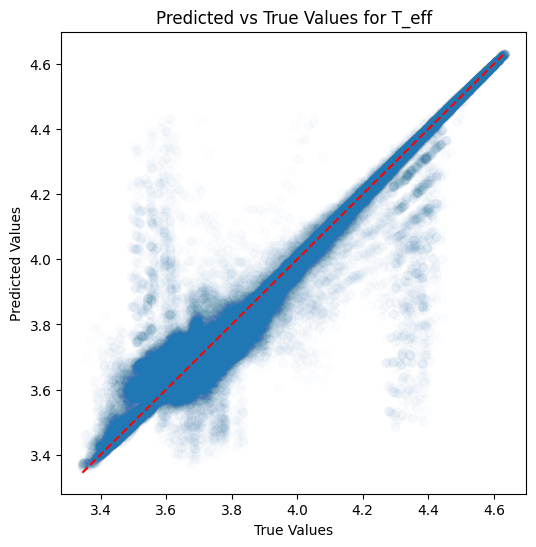

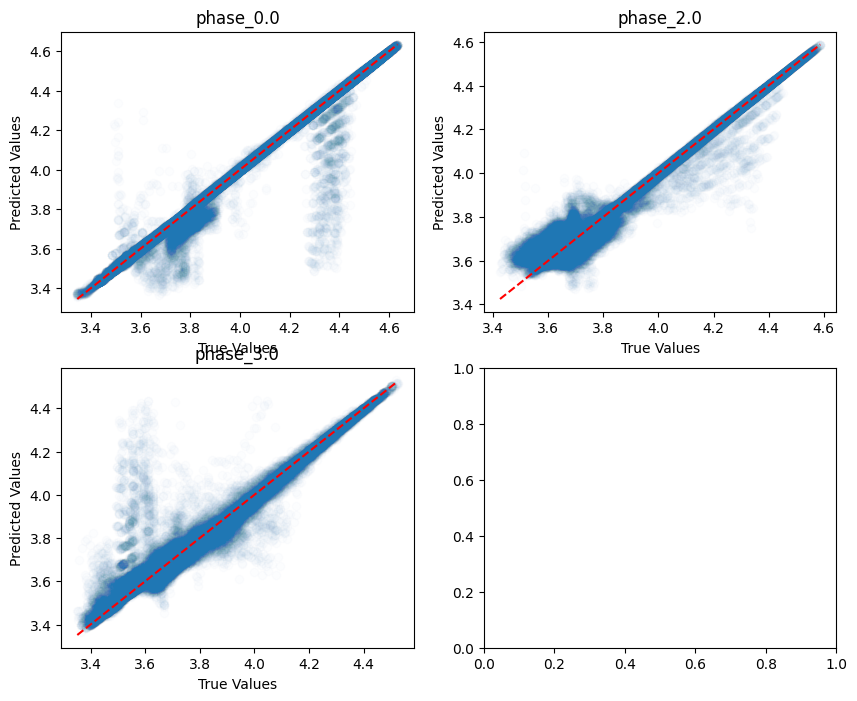

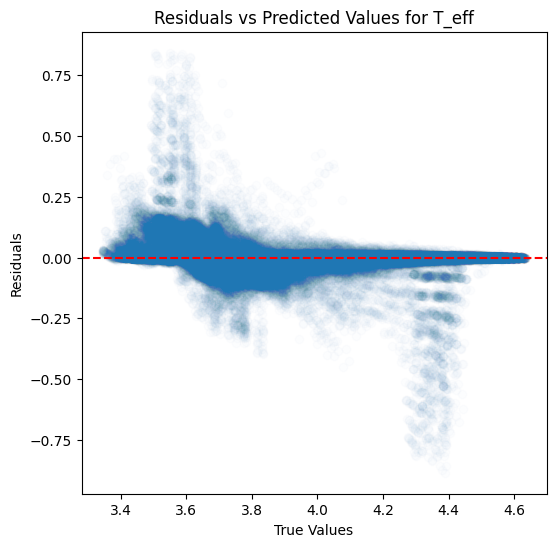

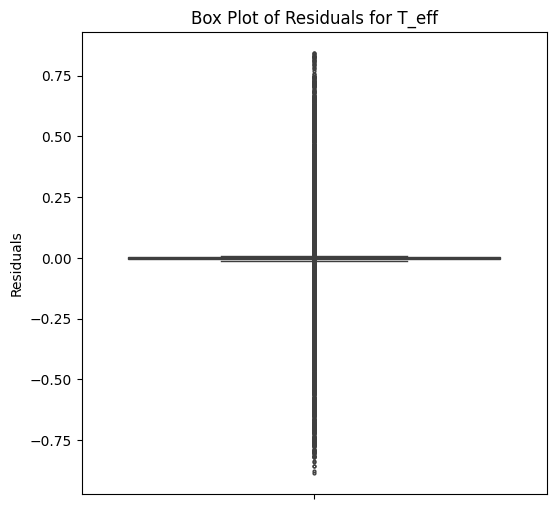

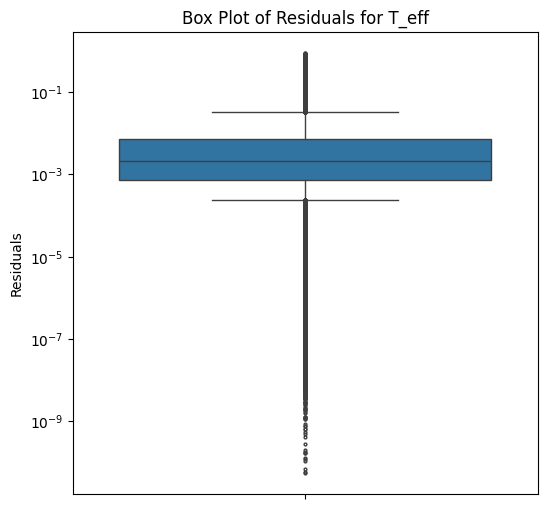

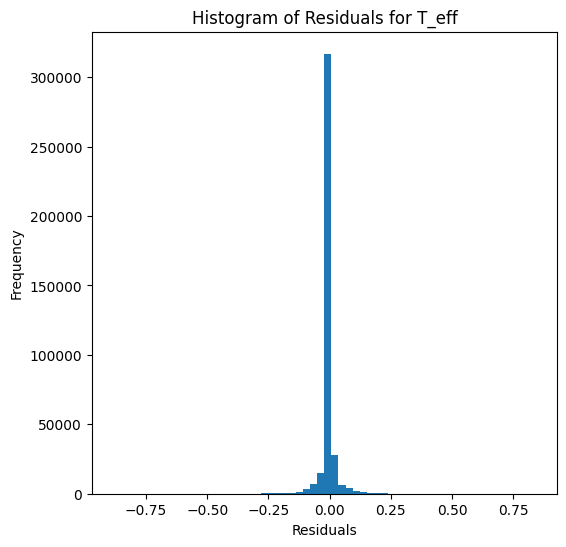

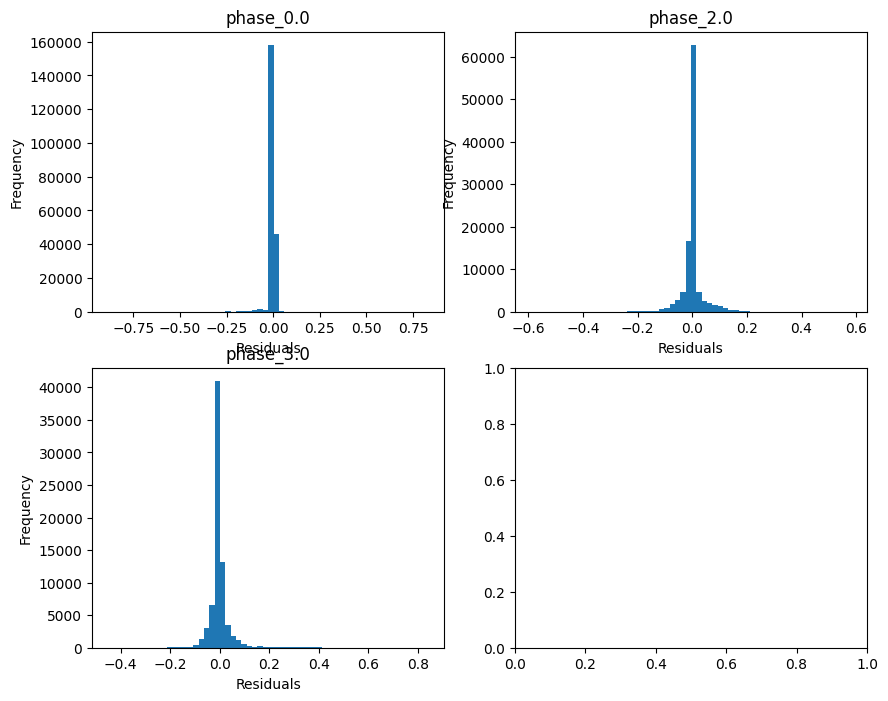

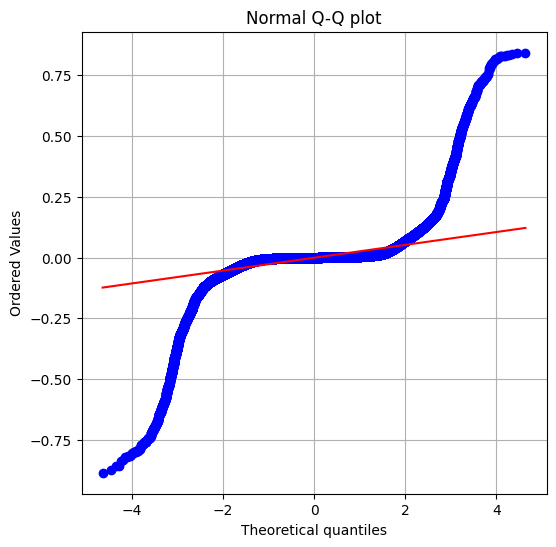

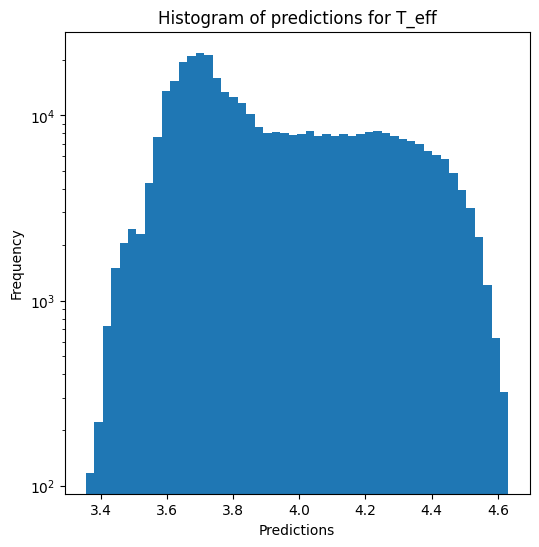

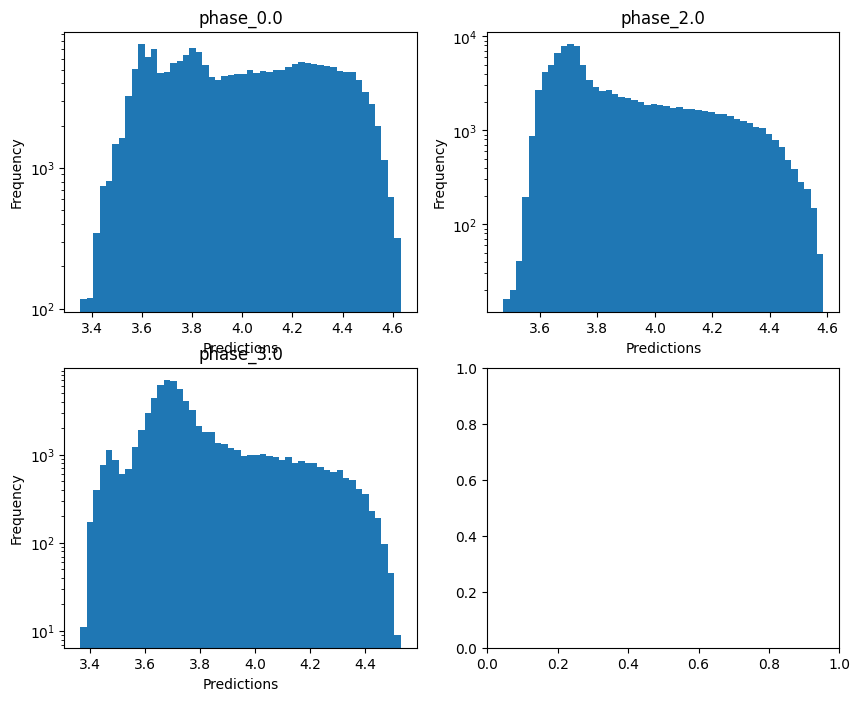


log_g results for the phase category with a value of 0.0
  value range :  -0.5973100835175252 - 5.433094523832443
  RVE :  0.5179428954812542
  RMSE :  0.31966693178499883
  MAE :  0.05300069352070176
  MedAE :  0.00318108568129416
  CORR :  0.835174874588507
  MAX_ER :  5.493119497182191
  Percentiles : 
    75th percentile :  0.009696534772409393
    90th percentile :  0.02213200276297105
    95th percentile :  0.037454938129167024
    99th percentile :  1.720601798785749

log_g results for the phase category with a value of 2.0
  value range :  -0.3287802371627256 - 4.4079093481651865
  RVE :  0.589582747188927
  RMSE :  0.5945917344100211
  MAE :  0.2858432200432656
  MedAE :  0.023784877648507674
  CORR :  0.7694713133818293
  MAX_ER :  3.91724779944122
  Percentiles : 
    75th percentile :  0.3183636683360199
    90th percentile :  1.0725981872813792
    95th percentile :  1.494414847679022
    99th percentile :  2.2238698616400514

log_g results for the phase category with a v

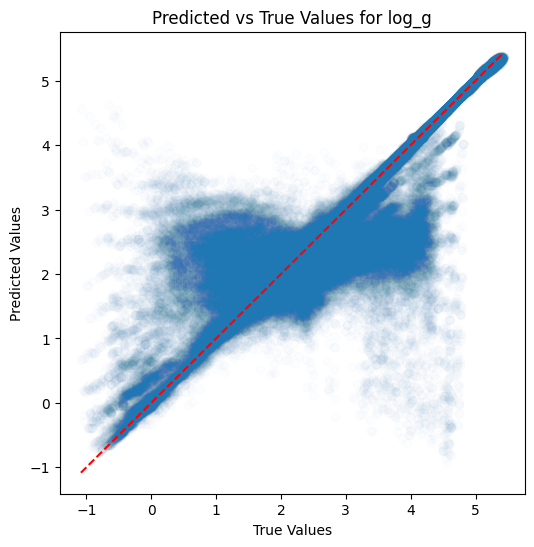

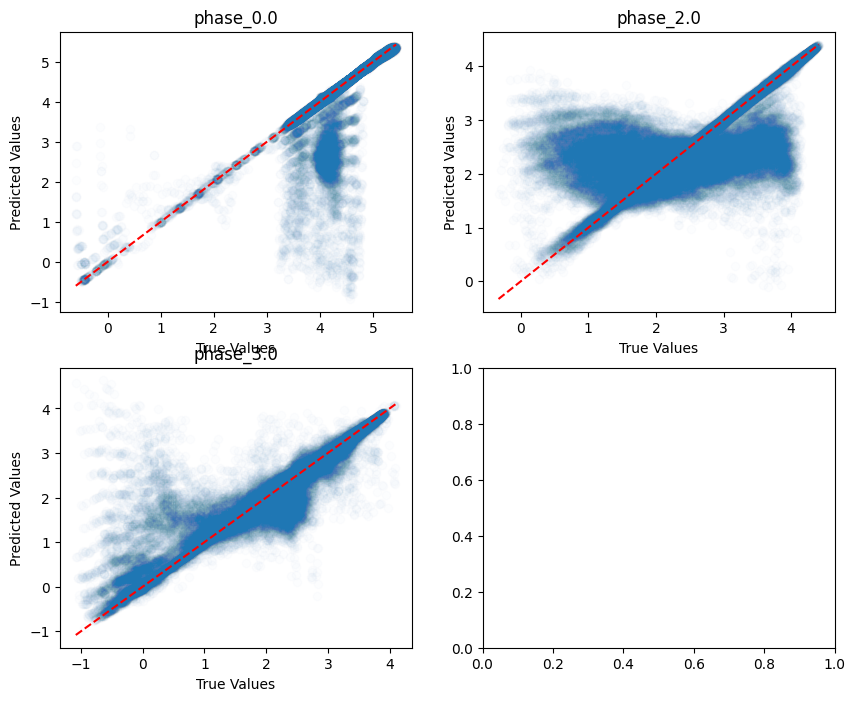

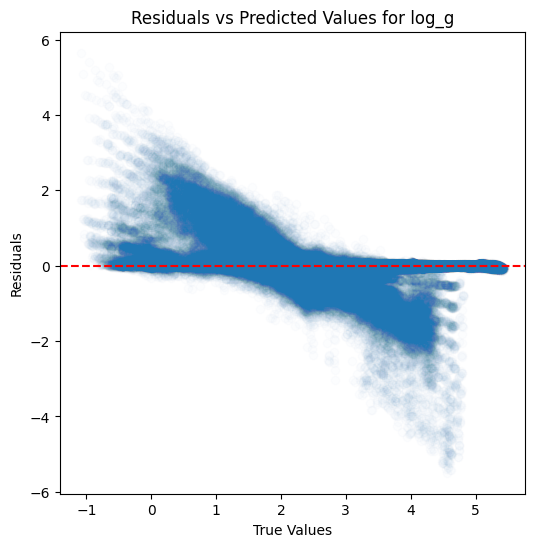

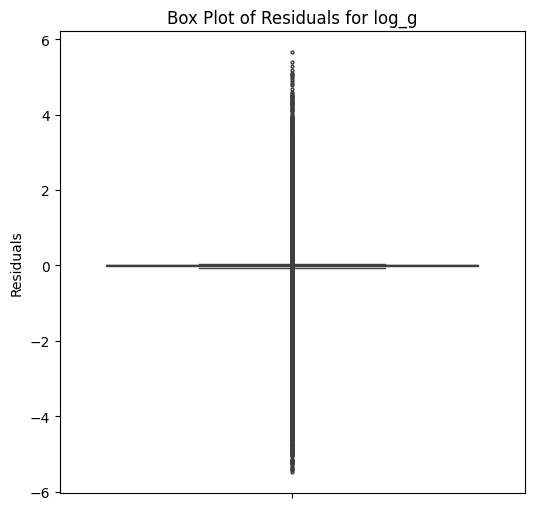

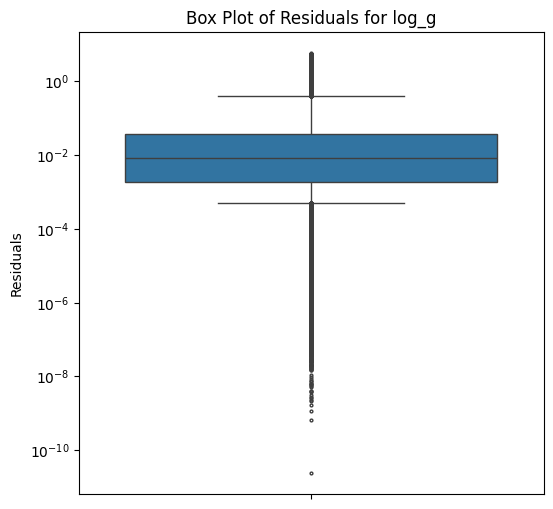

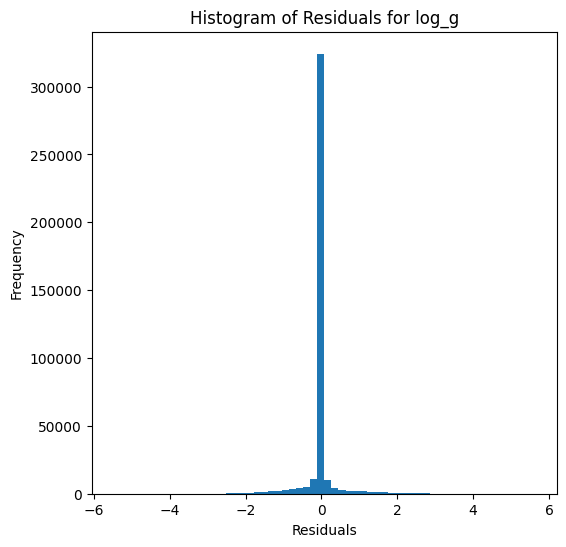

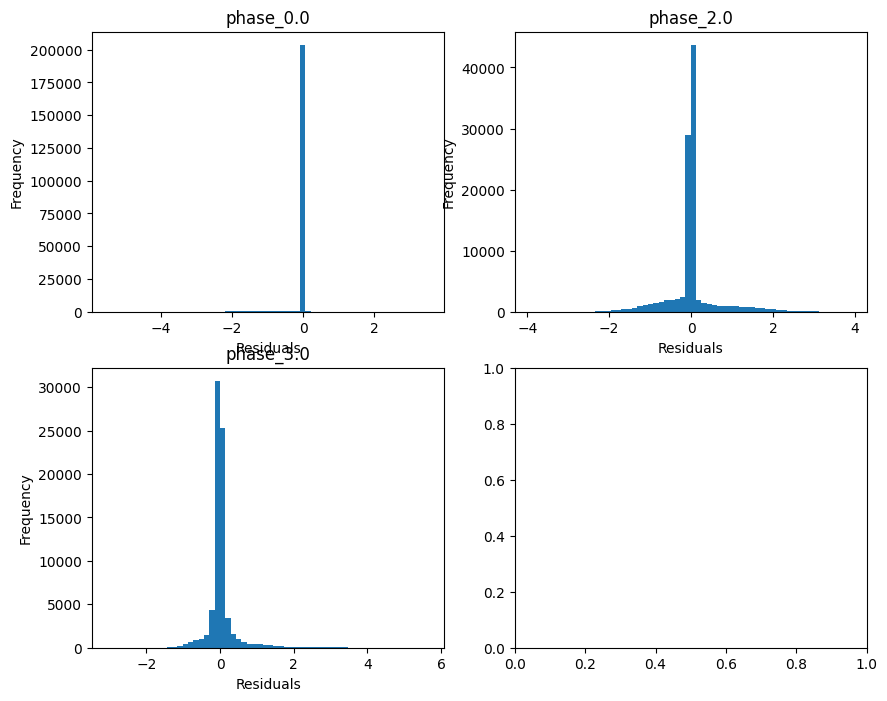

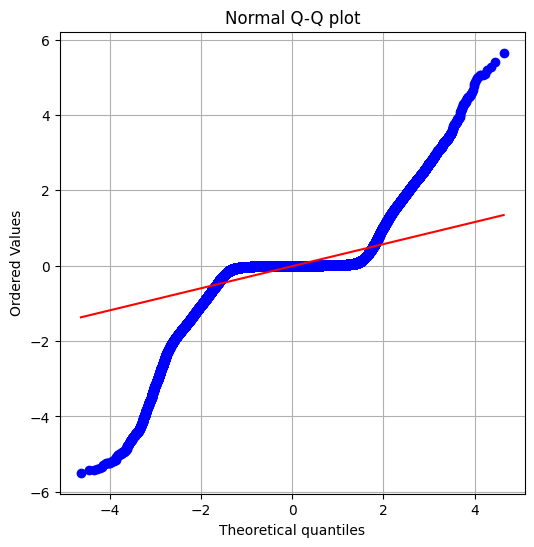

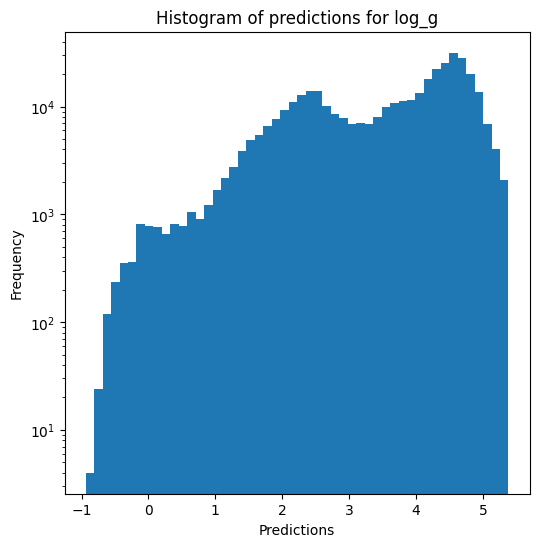

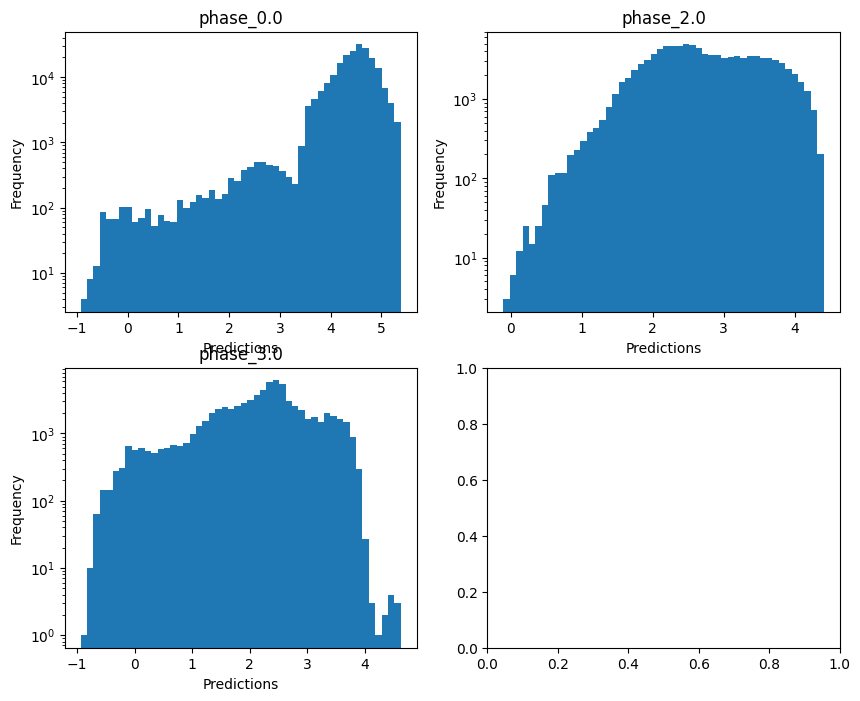

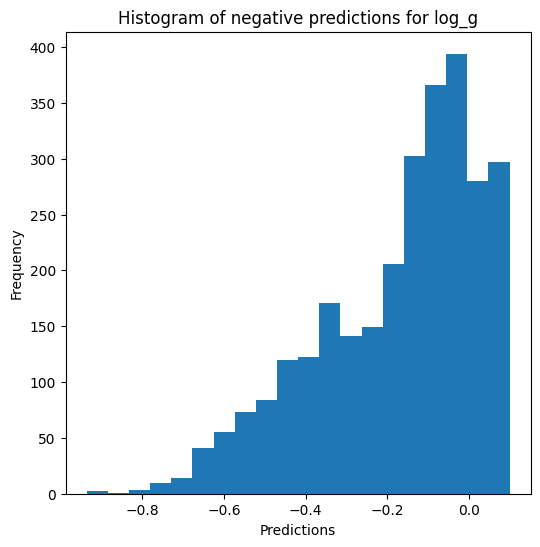


radius results for the phase category with a value of 0.0
  value range :  -0.9974747647513328 - 3.082068881511837
  RVE :  0.8585311005751463
  RMSE :  0.1600641149339176
  MAE :  0.028362160506471744
  MedAE :  0.0025962861160704342
  CORR :  0.9367080767600416
  MAX_ER :  2.747271008971443
  Percentiles : 
    75th percentile :  0.006901938657619233
    90th percentile :  0.015420704543454638
    95th percentile :  0.030529339649543925
    99th percentile :  0.8603207255867107

radius results for the phase category with a value of 2.0
  value range :  0.0909920840275404 - 2.8708569524681256
  RVE :  0.5921856284836302
  RMSE :  0.297293718771278
  MAE :  0.14293218451467207
  MedAE :  0.011920208007061062
  CORR :  0.7730079080305996
  MAX_ER :  1.95862659401026
  Percentiles : 
    75th percentile :  0.15916788154984596
    90th percentile :  0.5363036026721199
    95th percentile :  0.7471737727260931
    99th percentile :  1.1119587944688525

radius results for the phase categor

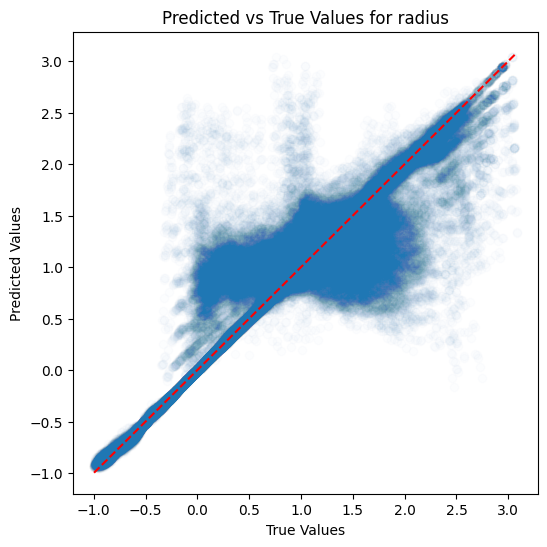

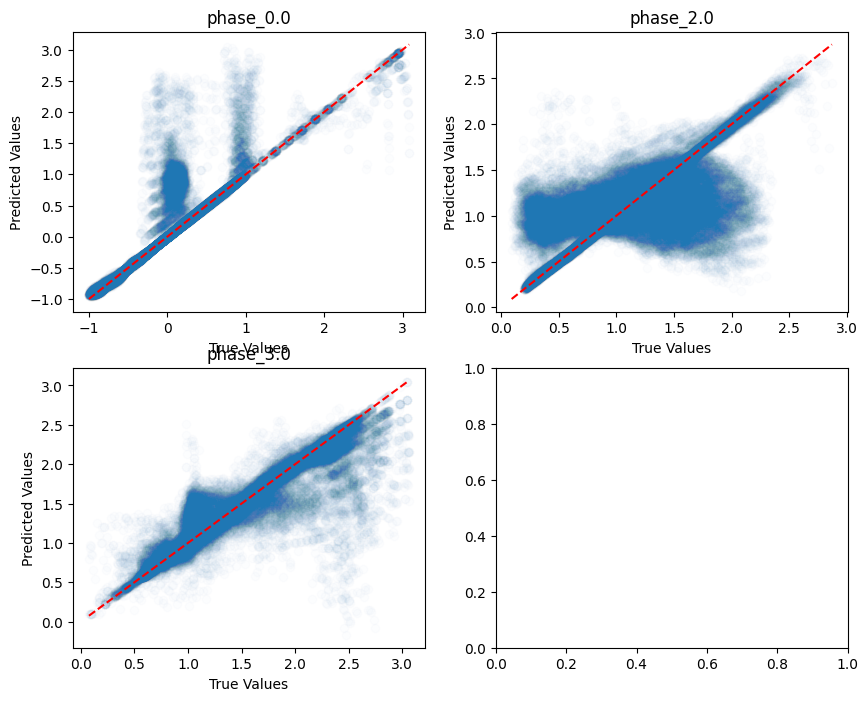

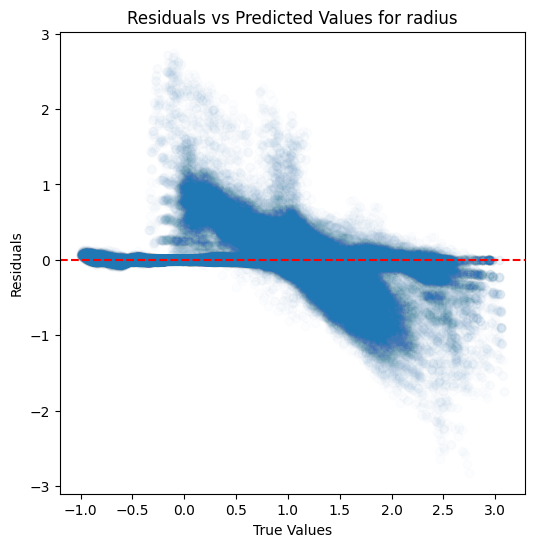

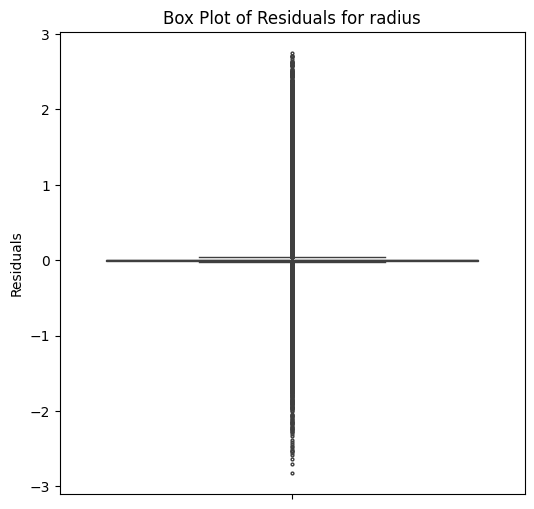

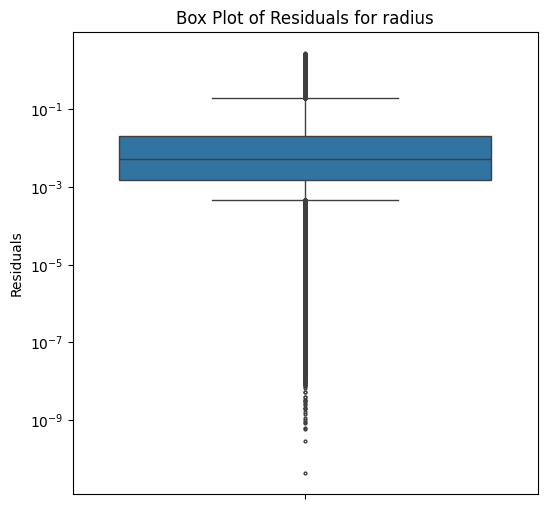

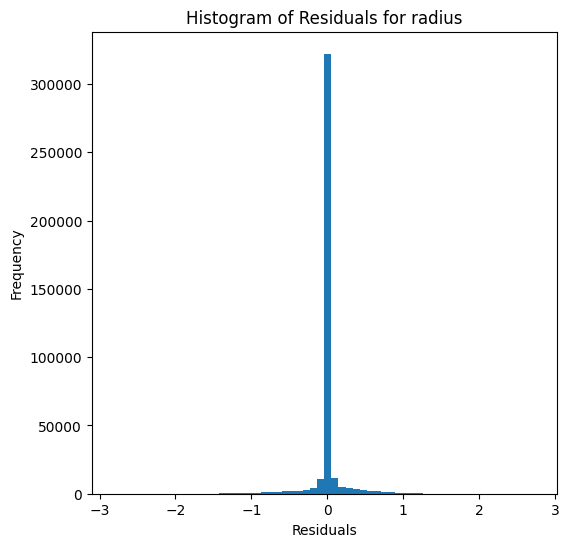

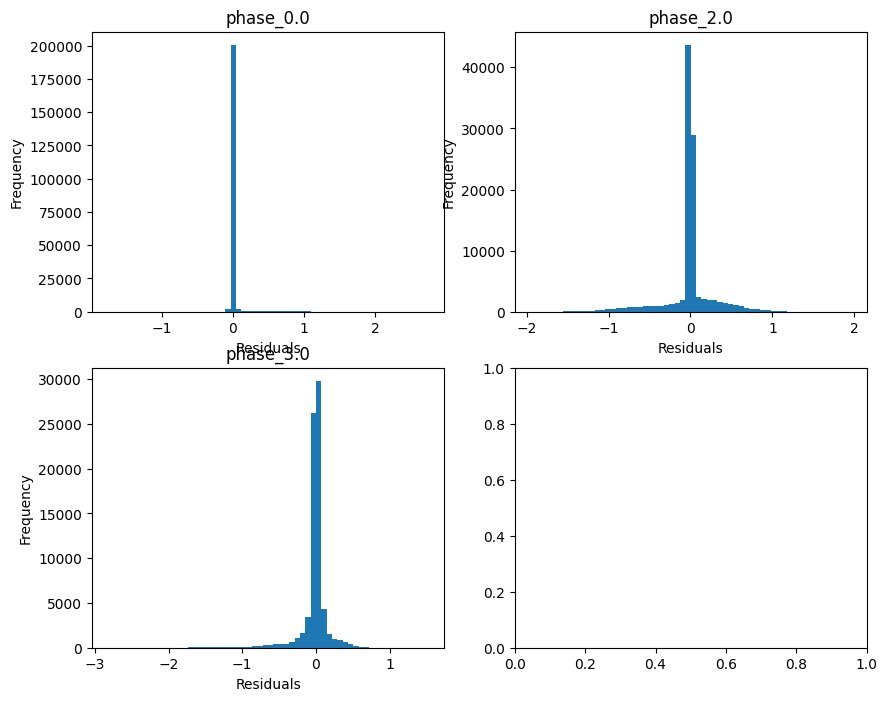

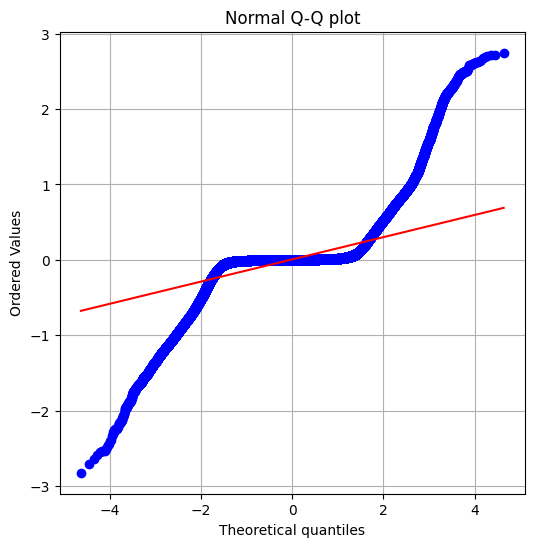

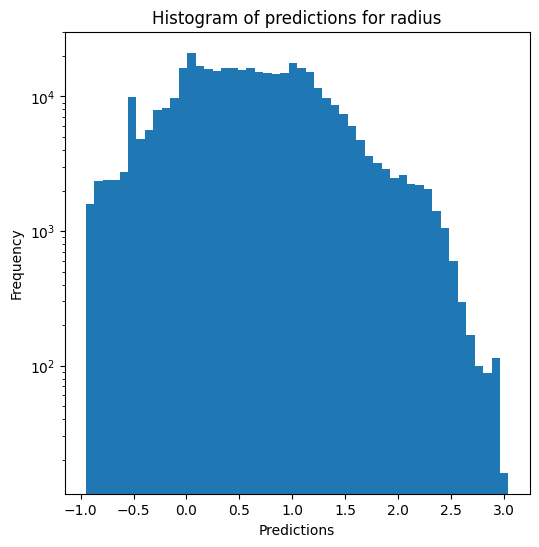

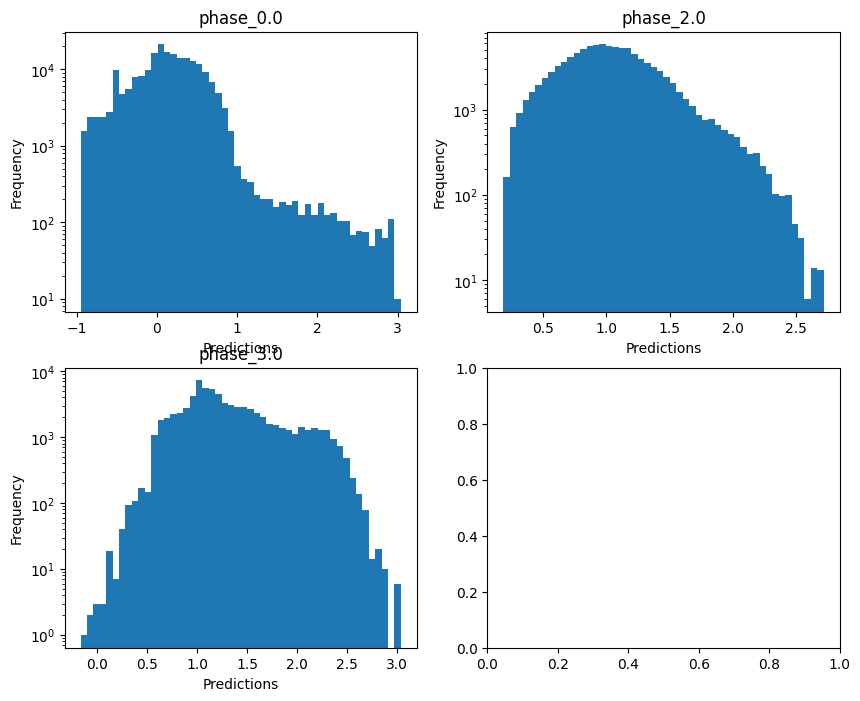

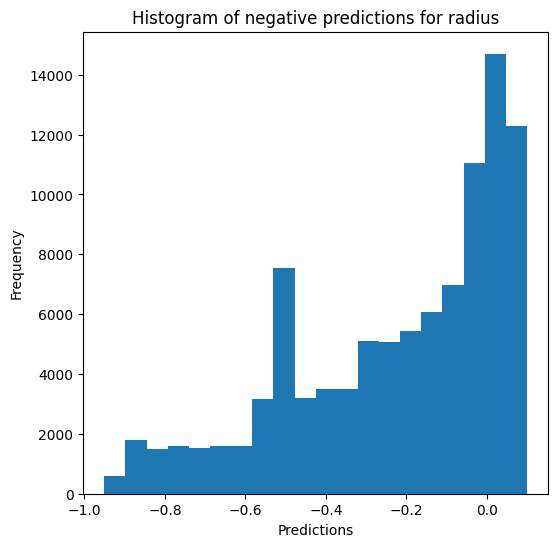

Saving predictions and results...


In [19]:
best_params_KNN = {'n_jobs' : 10, 'algorithm': 'ball_tree', 'leaf_size': 15, 'n_neighbors': 10, 'weights': 'uniform'}

print(path_to_results)
dt_evaluator = Model_evaluator("KNN", path=path_to_results, physical_model=physical_model, output_parameters=output_parameters)
dt_evaluator.evaluate_Kfold_results(KNeighborsRegressor, X_train, y_train, categories_train, categories_name, path_to_predictions, tag, random_state=12, override=override, use_preds=use_preds, save=save, show=show, scaler_name="quantile", **best_params_KNN)